# Exploratory Data Analysis (EDA) - Complete Teaching Notebook
**Instructor: Kajola Gbenga Adewale | Data Analytics Expert**

This notebook matches every slide in the EDA Teaching Deck.
Dataset: `eda_fintech_dataset.csv` - Nigerian FinTech customer transactions.

### Dataset Overview
- **5,000 rows x 23 columns**
- Nigerian FinTech customer transactions (Jan-Dec 2024)
- Target variable: `churned` (Yes/No) - 24% churn rate
- Key challenge: `amount` column is heavily right-skewed (mean=NGN 1.04M, median=NGN 188K)

### Columns
| Column | Type | Description |
|--------|------|-------------|
| customer_id | object | Unique customer identifier |
| date | datetime | Transaction date |
| month | object | Month name |
| month_num | int | Month number (1-12) |
| day_of_week | object | Day name |
| quarter | object | Q1/Q2/Q3/Q4 |
| age | int | Customer age |
| gender | object | Male/Female |
| region | object | Lagos/Abuja/Kano/Port Harcourt/Ibadan/Enugu |
| occupation | object | Customer occupation |
| segment | object | Retail/SME/Corporate/Premium/Student |
| product | object | Banking product used |
| channel | object | Mobile App/Web Portal/Branch/USSD/Agent Banking |
| amount | float | Transaction amount (NGN) - RIGHT SKEWED |
| balance | float | Account balance (NGN) |
| tenure_months | int | Months as customer |
| num_products | int | Number of products held |
| monthly_txn | int | Monthly transaction frequency |
| credit_score | int | Credit score (300-850) |
| satisfaction | float | Satisfaction score (1-10) |
| fees_paid | float | Fees paid on transaction |
| churned | object | Target variable: Yes/No |
| is_fraud | object | Fraud flag: Yes/No |


---
## CELL 01 - Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Global style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_theme(style='darkgrid', palette='Set2')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold'
})

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## STAGE 1 - Understand the Data (Slides 5-6)

In [2]:
# CELL 02 - Load the dataset
df = pd.read_csv('eda_fintech_dataset.csv')
print(f'Shape: {df.shape}')   # Expected: (5000, 23)
print(f'Columns: {df.columns.tolist()}')

Shape: (5000, 23)
Columns: ['customer_id', 'date', 'month', 'month_num', 'day_of_week', 'quarter', 'age', 'gender', 'region', 'occupation', 'segment', 'product', 'channel', 'amount', 'balance', 'tenure_months', 'num_products', 'monthly_txn', 'credit_score', 'satisfaction', 'fees_paid', 'churned', 'is_fraud']


In [3]:
# CELL 03 - First look
df.head(10)

,customer_id,date,month,month_num,day_of_week,quarter,age,gender,region,occupation,...,amount,balance,tenure_months,num_products,monthly_txn,credit_score,satisfaction,fees_paid,churned,is_fraud
0,CUST-01001,2024-07-11,July,7,Thursday,Q3,21,Female,Abuja,Entrepreneur,...,16000,104000,6,1,14,492,6.3,0,Yes,No
1,CUST-01002,2024-11-23,November,11,Saturday,Q4,40,Male,Abuja,Teacher,...,90000,736000,4,3,35,521,7.3,300,Yes,No
2,CUST-01003,2024-08-14,August,8,Wednesday,Q3,38,Male,Ibadan,Lawyer,...,2846000,35512000,42,2,35,653,7.7,5700,No,No
3,CUST-01004,2024-05-05,May,5,Sunday,Q2,55,Female,Enugu,Accountant,...,445000,4145000,21,4,22,570,8.5,900,No,No
4,CUST-01005,2024-11-15,November,11,Friday,Q4,21,Female,Ibadan,Doctor,...,17000,147000,20,2,25,475,6.3,0,No,No
5,CUST-01006,2024-04-19,April,4,Friday,Q2,37,Female,Enugu,Civil Servant,...,45000,402000,98,1,33,425,7.6,0,Yes,No
6,CUST-01007,2024-03-10,March,3,Sunday,Q1,18,Male,Enugu,Teacher,...,23000,137000,51,5,15,609,8.9,0,No,No
7,CUST-01008,2024-12-11,December,12,Wednesday,Q4,39,Male,Abuja,Farmer,...,206000,194000,97,2,34,602,6.5,400,No,No
8,CUST-01009,2024-11-13,November,11,Wednesday,Q4,28,Male,Abuja,Doctor,...,157000,388000,81,5,39,499,7.4,200,No,No
9,CUST-01010,2024-06-28,June,6,Friday,Q2,44,Male,Port Harcourt,Engineer,...,3652000,47192000,1,5,8,771,8.1,3700,No,No


In [4]:
# CELL 04 - Info: dtypes and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customer_id    5000 non-null   object 
 1   date           5000 non-null   object 
 2   month          5000 non-null   object 
 3   month_num      5000 non-null   int64  
 4   day_of_week    5000 non-null   object 
 5   quarter        5000 non-null   object 
 6   age            5000 non-null   int64  
 7   gender         5000 non-null   object 
 8   region         5000 non-null   object 
 9   occupation     5000 non-null   object 
 10  segment        5000 non-null   object 
 11  product        5000 non-null   object 
 12  channel        5000 non-null   object 
 13  amount         5000 non-null   int64  
 14  balance        5000 non-null   int64  
 15  tenure_months  5000 non-null   int64  
 16  num_products   5000 non-null   int64  
 17  monthly_txn    5000 non-null   int64  
 18  credit_s

In [5]:
# CELL 05 - Statistical summary of numeric columns
df.describe().round(2)

,month_num,age,amount,balance,tenure_months,num_products,monthly_txn,credit_score,satisfaction,fees_paid
count,5000.00,5000.00,5000.00,5000.0,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,6.52,37.60,1036994.00,8002688.0,61.45,2.41,22.84,595.03,7.14,1973.78
std,3.41,11.47,3266707.51,29768668.5,34.33,1.25,13.08,131.84,1.72,6625.13
min,1.00,18.00,2000.00,3000.0,1.00,1.00,1.00,300.00,1.00,0.00
25%,4.00,29.00,41000.00,244750.0,32.00,1.00,11.00,491.00,6.00,100.00
50%,6.00,37.00,188000.00,1202500.0,62.00,2.00,23.00,598.00,7.20,300.00
75%,9.00,45.00,682000.00,4856750.0,91.00,3.00,34.00,706.00,8.40,1200.00
max,12.00,72.00,50000000.00,665655000.0,120.00,5.00,45.00,850.00,10.00,150000.00


In [6]:
# CELL 06 - Statistical summary of text columns
df.describe(include='object')

,customer_id,date,month,day_of_week,quarter,gender,region,occupation,segment,product,channel,churned,is_fraud
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000
unique,5000,365,12,7,4,2,6,10,5,8,5,2,2
top,CUST-01001,2024-11-30,April,Sunday,Q2,Male,Enugu,Doctor,Retail,Investment Fund,Mobile App,No,No
freq,1,29,444,735,1312,2517,860,541,1551,658,1711,3801,4988


In [7]:
# CELL 07 - Missing values check
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values - clean dataset!')
print(f'Total nulls: {df.isnull().sum().sum()}')

Missing values per column:
No missing values - clean dataset!
Total nulls: 0


In [8]:
# CELL 08 - Unique value counts (cardinality)
print('Unique values per column:')
print(df.nunique())

Unique values per column:
customer_id      5000
date              365
month              12
month_num          12
day_of_week         7
quarter             4
age                55
gender              2
region              6
occupation         10
segment             5
product             8
channel             5
amount           1665
balance          3143
tenure_months     120
num_products        5
monthly_txn        45
credit_score      548
satisfaction       87
fees_paid         239
churned             2
is_fraud            2
dtype: int64


In [9]:
# CELL 09 - Category distributions
for col in ['region', 'segment', 'channel', 'gender', 'churned', 'is_fraud']:
    print(f'\n{col}:')
    print(df[col].value_counts())
    print(f'Churn rate: {(df["churned"]=="Yes").mean()*100:.1f}%' if col == 'churned' else '')


region:
region
Enugu            860
Ibadan           854
Abuja            850
Kano             833
Lagos            805
Port Harcourt    798
Name: count, dtype: int64


segment:
segment
Retail       1551
Student      1144
SME           855
Corporate     734
Premium       716
Name: count, dtype: int64


channel:
channel
Mobile App       1711
Branch           1027
Web Portal       1013
USSD              801
Agent Banking     448
Name: count, dtype: int64


gender:
gender
Male      2517
Female    2483
Name: count, dtype: int64


churned:
churned
No     3801
Yes    1199
Name: count, dtype: int64
Churn rate: 24.0%

is_fraud:
is_fraud
No     4988
Yes      12
Name: count, dtype: int64



In [10]:
# CELL 10 - Separate numeric and categorical columns
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Numeric columns ({len(num_cols)}): {num_cols}')
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

Numeric columns (10): ['month_num', 'age', 'amount', 'balance', 'tenure_months', 'num_products', 'monthly_txn', 'credit_score', 'satisfaction', 'fees_paid']
Categorical columns (13): ['customer_id', 'date', 'month', 'day_of_week', 'quarter', 'gender', 'region', 'occupation', 'segment', 'product', 'channel', 'churned', 'is_fraud']


In [11]:
# CELL 11 - Quick summary stats for key numeric columns
key_stats = df[['amount', 'credit_score', 'satisfaction', 'tenure_months', 'age']].agg(
    ['mean', 'median', 'std', 'min', 'max', 'skew']
).round(2)
print('Key Statistics:')
print(key_stats)
print('\nINSIGHT: amount mean (1,036,994) >> median (188,000) = RIGHT SKEWED')

Key Statistics:
             amount  credit_score  satisfaction  tenure_months    age
mean     1036994.00        595.03          7.14          61.45  37.60
median    188000.00        598.00          7.20          62.00  37.00
std      3266707.51        131.84          1.72          34.33  11.47
min         2000.00        300.00          1.00           1.00  18.00
max     50000000.00        850.00         10.00         120.00  72.00
skew           8.92         -0.16         -0.30          -0.05   0.26

INSIGHT: amount mean (1,036,994) >> median (188,000) = RIGHT SKEWED


---
## STAGE 2 - Univariate Analysis (Slides 7-11)

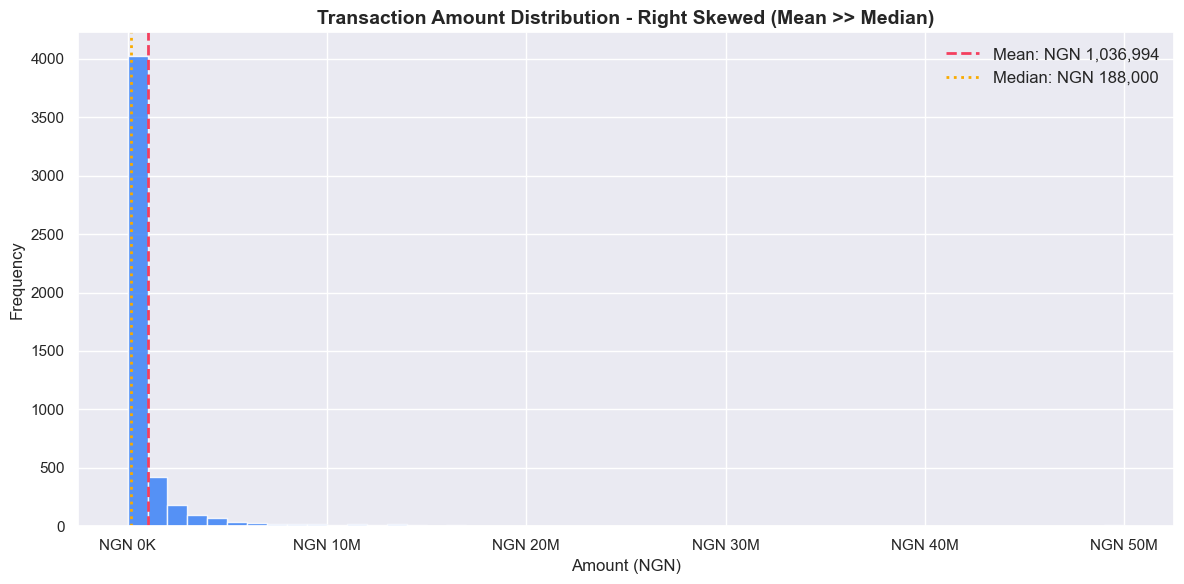

Skewness: 8.92  (positive = right skewed)


In [12]:
# CELL 12 - Histogram of amount column (right-skewed)
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df['amount'], bins=50, color='#3B82F6', edgecolor='white', alpha=0.85)

# Mean and median reference lines
ax.axvline(df['amount'].mean(),
           color='#F43F5E', linestyle='--', linewidth=2,
           label=f'Mean: NGN {df["amount"].mean():,.0f}')
ax.axvline(df['amount'].median(),
           color='#F9AB00', linestyle=':', linewidth=2,
           label=f'Median: NGN {df["amount"].median():,.0f}')

ax.set_title('Transaction Amount Distribution - Right Skewed (Mean >> Median)')
ax.set_xlabel('Amount (NGN)')
ax.set_ylabel('Frequency')
ax.legend(fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'NGN {x/1e6:.0f}M' if x >= 1e6 else f'NGN {x/1e3:.0f}K'))
plt.tight_layout()
plt.show()
print(f'Skewness: {df["amount"].skew():.2f}  (positive = right skewed)')

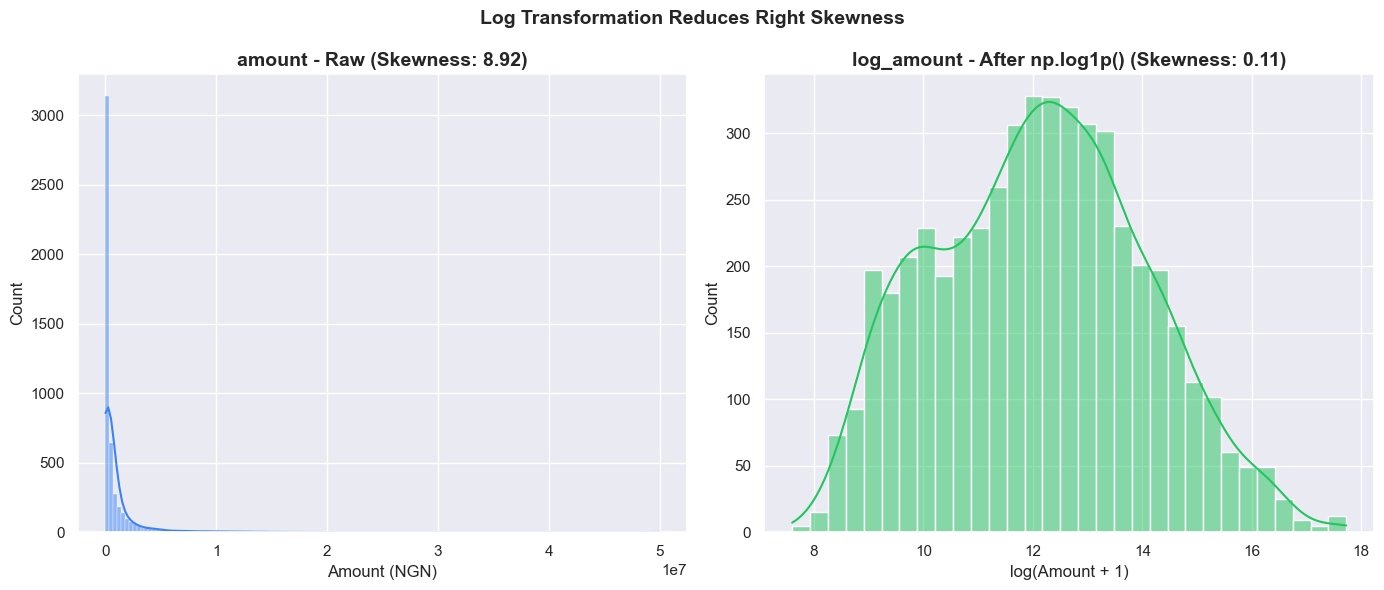

In [13]:
# CELL 13 - KDE plot and log transformation comparison
df['log_amount'] = np.log1p(df['amount'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw amount
sns.histplot(df['amount'], kde=True, ax=axes[0], color='#3B82F6')
axes[0].set_title(f'amount - Raw (Skewness: {df["amount"].skew():.2f})')
axes[0].set_xlabel('Amount (NGN)')

# Log-transformed
sns.histplot(df['log_amount'], kde=True, ax=axes[1], color='#22C55E')
axes[1].set_title(f'log_amount - After np.log1p() (Skewness: {df["log_amount"].skew():.2f})')
axes[1].set_xlabel('log(Amount + 1)')

plt.suptitle('Log Transformation Reduces Right Skewness', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# CELL 14 - Skewness for all numeric columns
skewness = df[num_cols].skew().sort_values(ascending=False).round(3)
print('Skewness per column (positive = right-skewed, negative = left-skewed):')
print(skewness)
print('\nRule: abs(skewness) > 1 = significantly skewed, consider log transform')

Skewness per column (positive = right-skewed, negative = left-skewed):
balance          12.338
fees_paid        10.437
amount            8.919
num_products      0.529
age               0.256
month_num         0.002
monthly_txn      -0.008
tenure_months    -0.052
credit_score     -0.157
satisfaction     -0.299
dtype: float64

Rule: abs(skewness) > 1 = significantly skewed, consider log transform


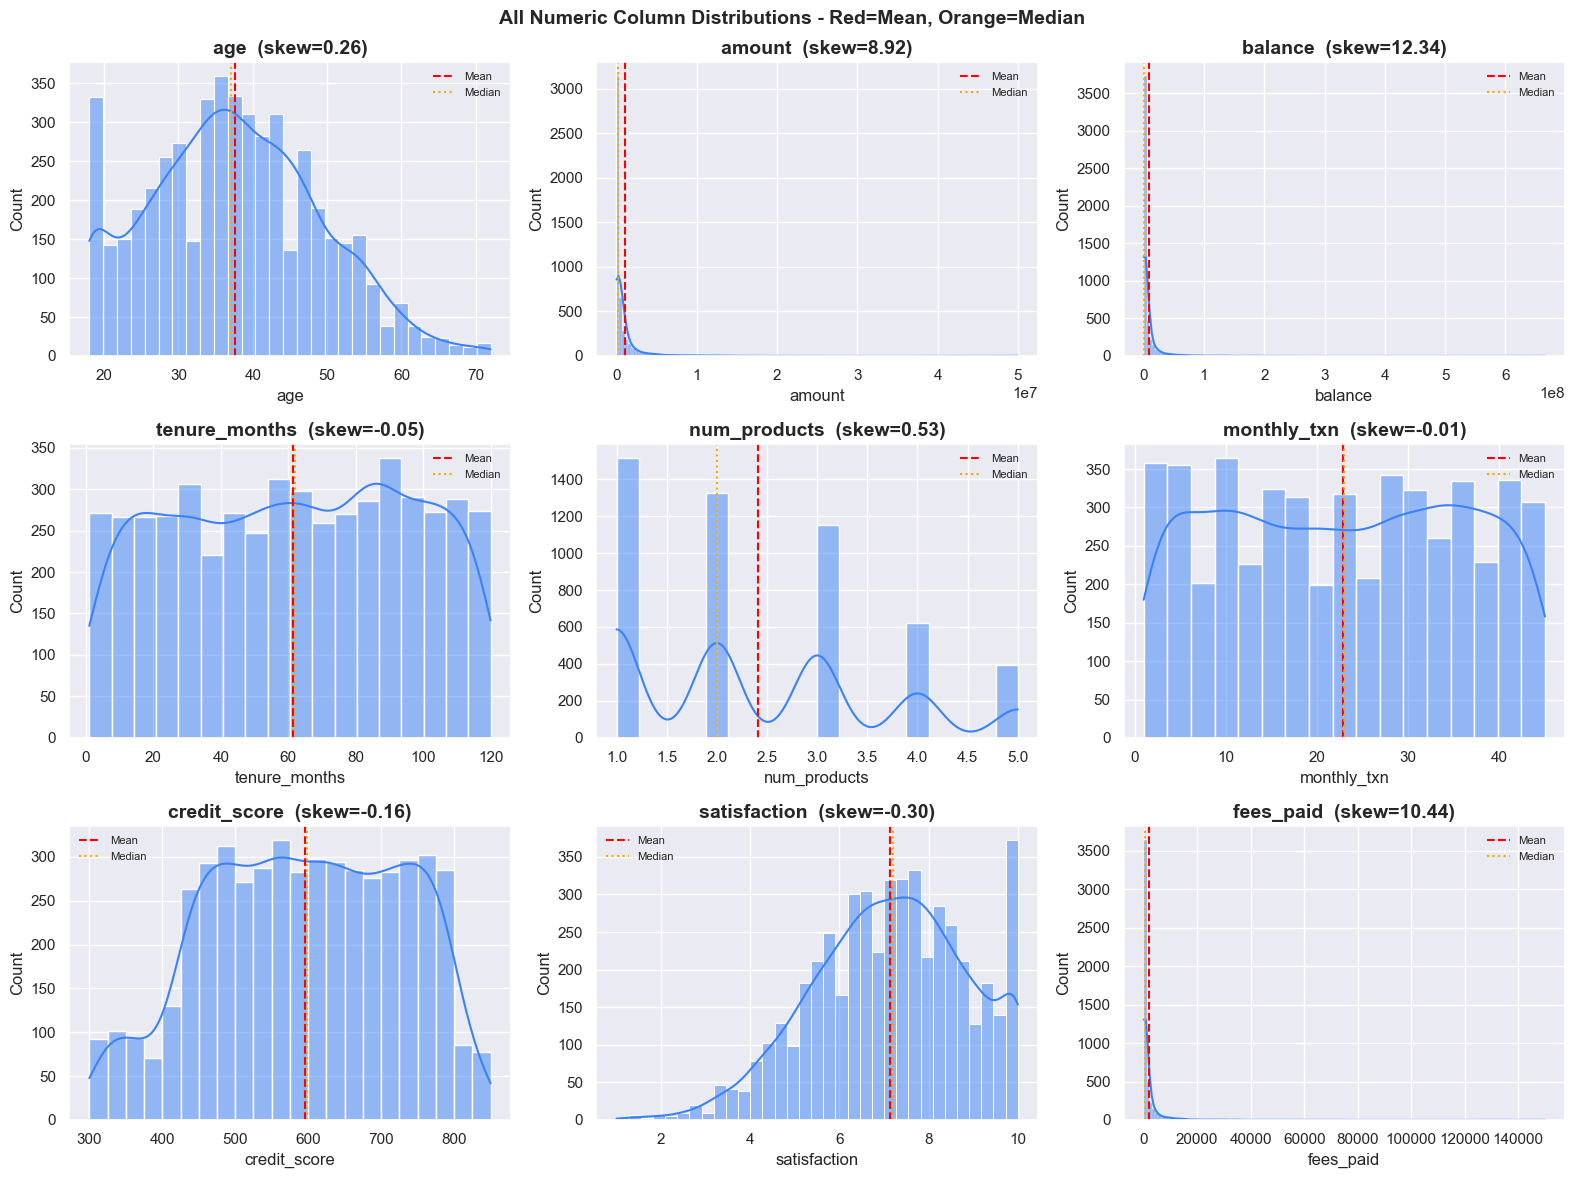

In [15]:
# CELL 15 - All numeric distributions in one grid (3x3 subplots)
num_to_plot = ['age', 'amount', 'balance', 'tenure_months',
               'num_products', 'monthly_txn', 'credit_score', 'satisfaction', 'fees_paid']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for i, col in enumerate(num_to_plot):
    ax = axes[i//3][i%3]
    sns.histplot(df[col], kde=True, ax=ax, color='#3B82F6')
    ax.set_title(f'{col}  (skew={df[col].skew():.2f})')
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.5, label='Mean')
    ax.axvline(df[col].median(), color='orange', linestyle=':',  linewidth=1.5, label='Median')
    ax.legend(fontsize=8)

plt.suptitle('All Numeric Column Distributions - Red=Mean, Orange=Median', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

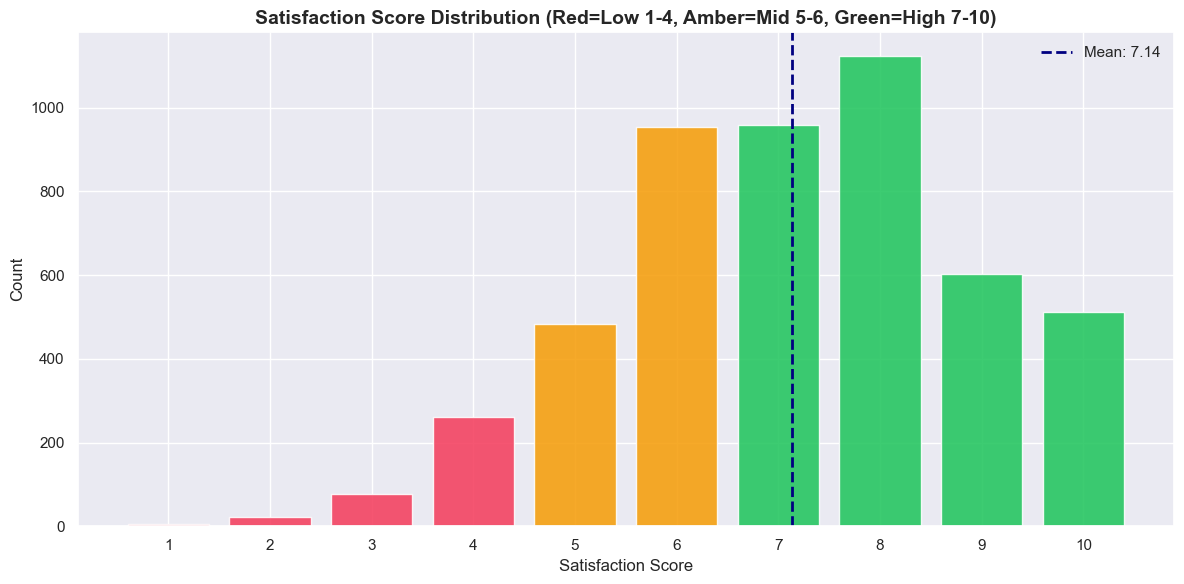

Mean: 7.14  Median: 7.20
Customers with score 1-4 (churn risk): 208


In [16]:
# CELL 16 - Satisfaction score distribution
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#F43F5E' if i <= 4 else '#F59E0B' if i <= 6 else '#22C55E' for i in range(1, 11)]

for score in range(1, 11):
    count = (df['satisfaction'].round() == score).sum()
    ax.bar(score, count, color=colors[score-1], edgecolor='white', alpha=0.88)

ax.set_xticks(range(1, 11))
ax.set_xlabel('Satisfaction Score')
ax.set_ylabel('Count')
ax.set_title('Satisfaction Score Distribution (Red=Low 1-4, Amber=Mid 5-6, Green=High 7-10)')
ax.axvline(df['satisfaction'].mean(), color='navy', linestyle='--', linewidth=2, label=f'Mean: {df["satisfaction"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Mean: {df["satisfaction"].mean():.2f}  Median: {df["satisfaction"].median():.2f}')
print(f'Customers with score 1-4 (churn risk): {(df["satisfaction"] <= 4).sum():,}')

C:\Users\user\AppData\Local\Temp\ipykernel_21824\235765577.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='Set2', ax=ax)
C:\Users\user\AppData\Local\Temp\ipykernel_21824\235765577.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='Set2', ax=ax)
C:\Users\user\AppData\Local\Temp\ipykernel_21824\235765577.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='Set2', ax=ax)
C:\Users\user\AppData\Local\Temp\ipykernel_21824\235

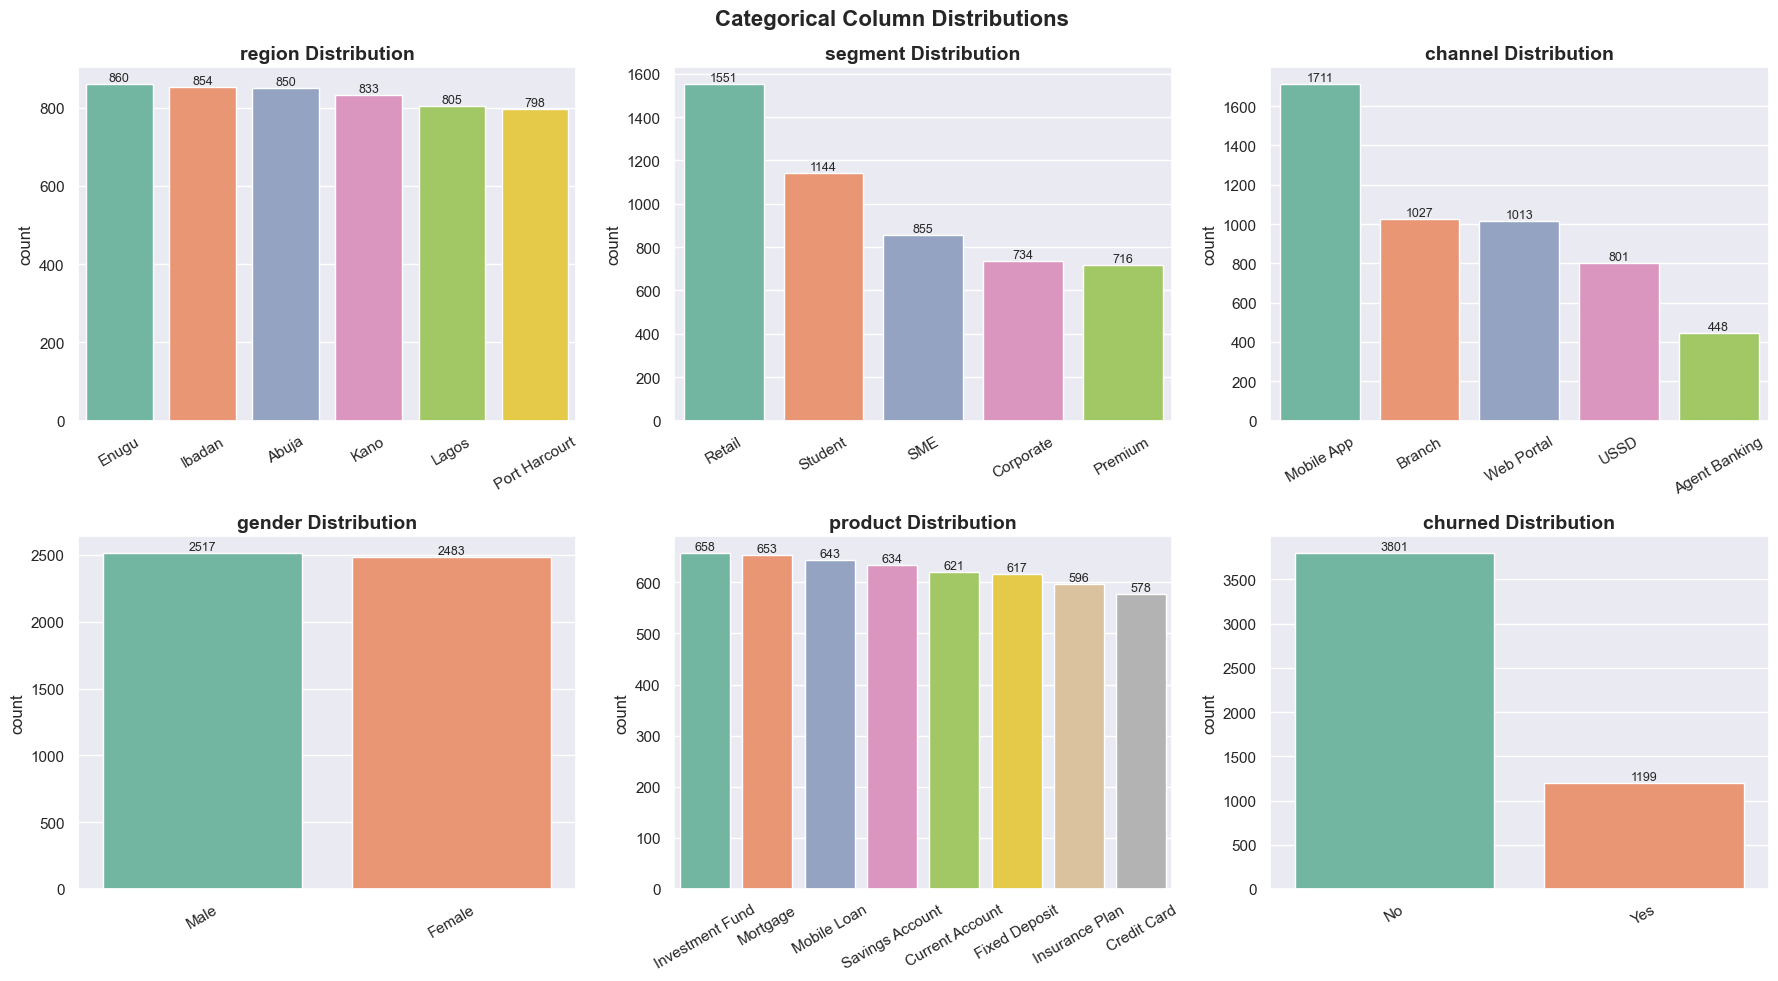

In [17]:
# CELL 17 - Categorical count plots - 6-panel grid
cat_to_plot = ['region', 'segment', 'channel', 'gender', 'product', 'churned']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(cat_to_plot):
    ax = axes[i//3][i%3]
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette='Set2', ax=ax)
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    # Add count labels on bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Categorical Column Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

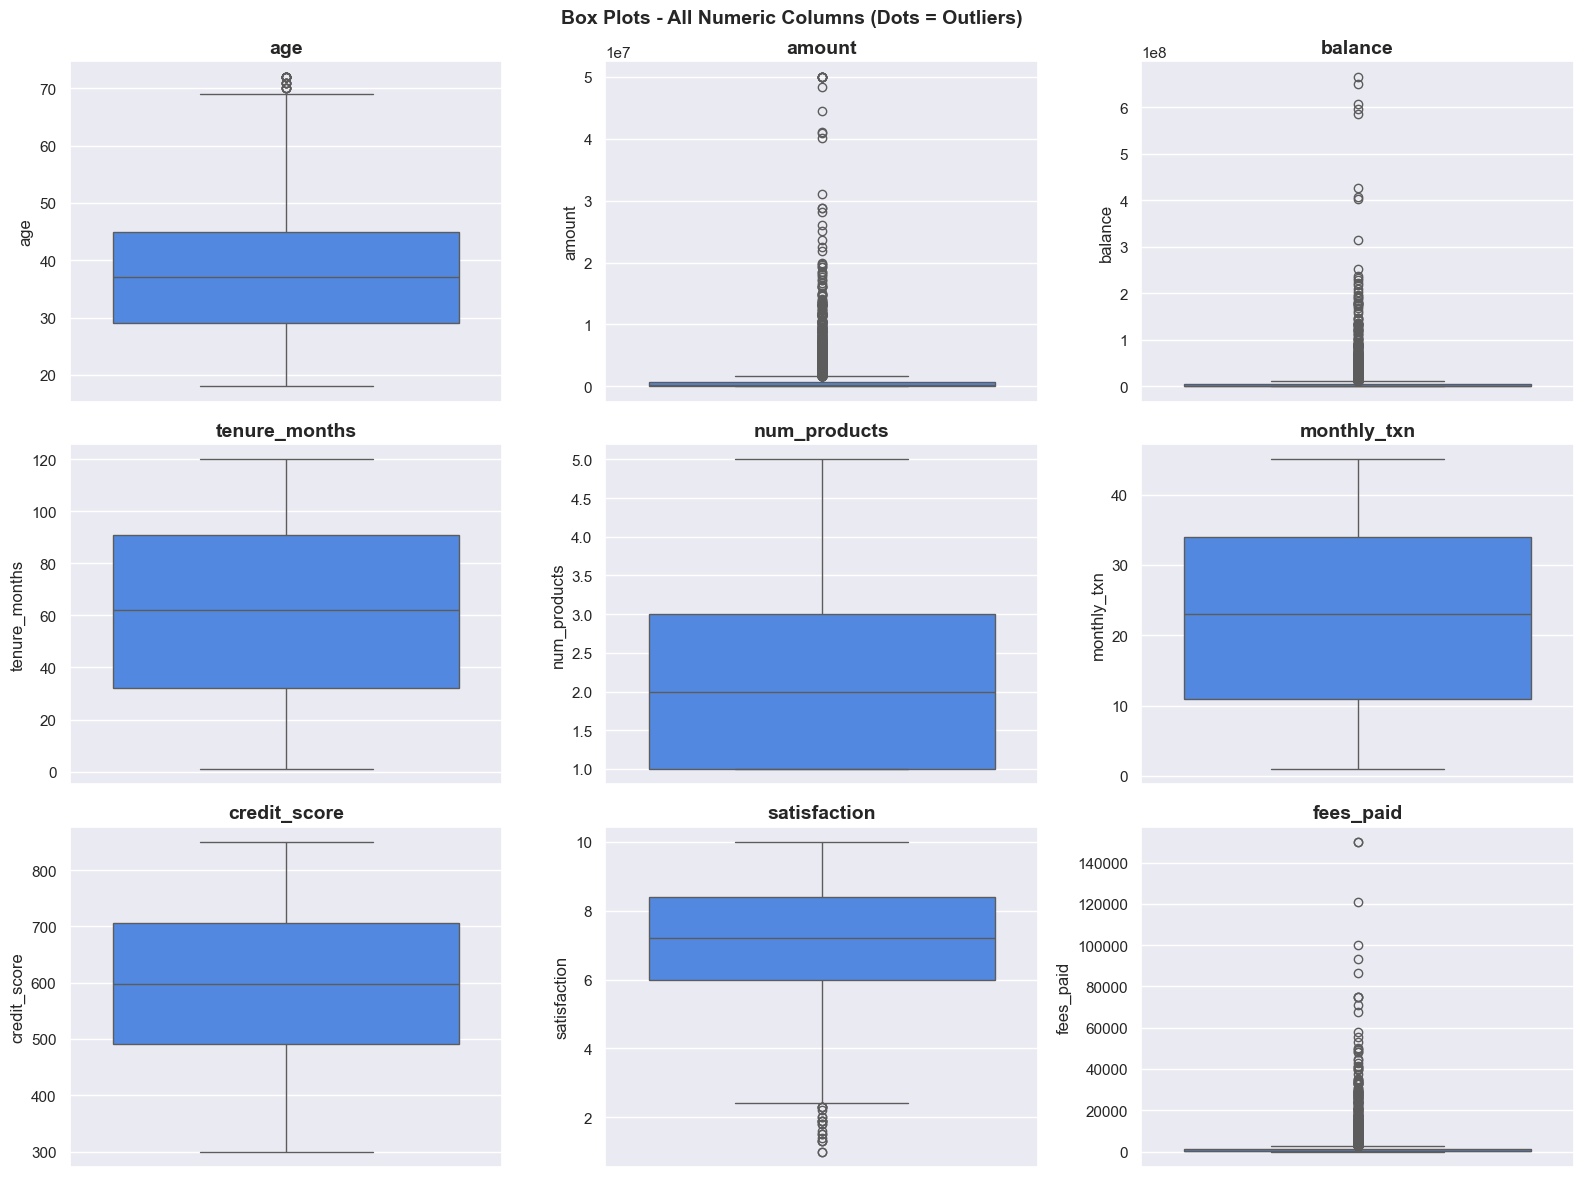

In [18]:
# CELL 18 - Box plots for all numeric columns (outlier detection)
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for i, col in enumerate(num_to_plot):
    ax = axes[i//3][i%3]
    sns.boxplot(data=df, y=col, ax=ax, color='#3B82F6')
    ax.set_title(f'{col}')

plt.suptitle('Box Plots - All Numeric Columns (Dots = Outliers)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## STAGE 3 - Bivariate Analysis (Slides 12-15)

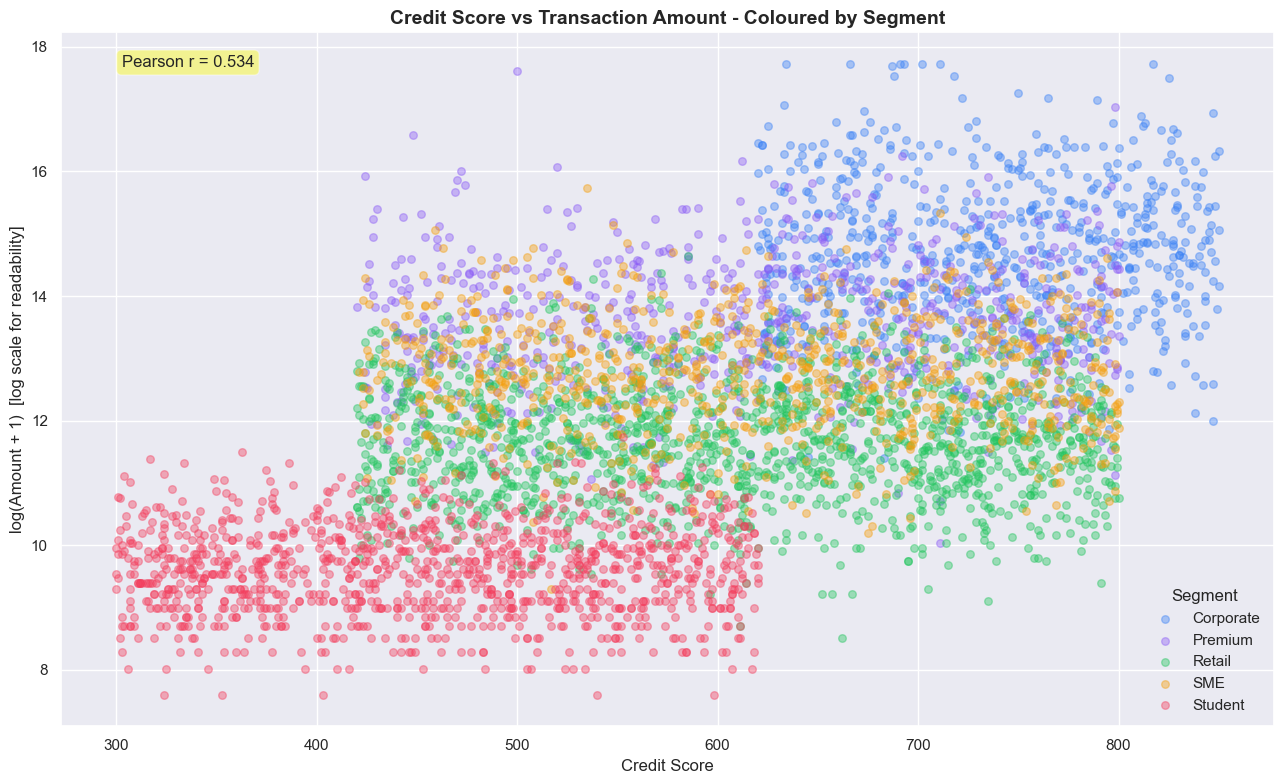

Insight: Corporate clusters top-right (high credit, high amount). Student clusters bottom-left.


In [19]:
# CELL 19 - Scatter plot: credit_score vs amount by segment
fig, ax = plt.subplots(figsize=(13, 8))

colors = {'Corporate':'#3B82F6','Premium':'#8B5CF6',
           'SME':'#F59E0B','Retail':'#22C55E','Student':'#F43F5E'}

for seg, grp in df.groupby('segment'):
    ax.scatter(grp['credit_score'],
               np.log1p(grp['amount']),
               label=seg,
               alpha=0.4, s=30,
               color=colors[seg])

ax.set_xlabel('Credit Score')
ax.set_ylabel('log(Amount + 1)  [log scale for readability]')
ax.set_title('Credit Score vs Transaction Amount - Coloured by Segment')
ax.legend(title='Segment', fontsize=11)

# Correlation annotation
r = df['credit_score'].corr(np.log1p(df['amount']))
ax.text(0.05, 0.95, f'Pearson r = {r:.3f}',
        transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.4),
        fontsize=12)

plt.tight_layout()
plt.show()
print(f'Insight: Corporate clusters top-right (high credit, high amount). Student clusters bottom-left.')

C:\Users\user\AppData\Local\Temp\ipykernel_21824\1384898738.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


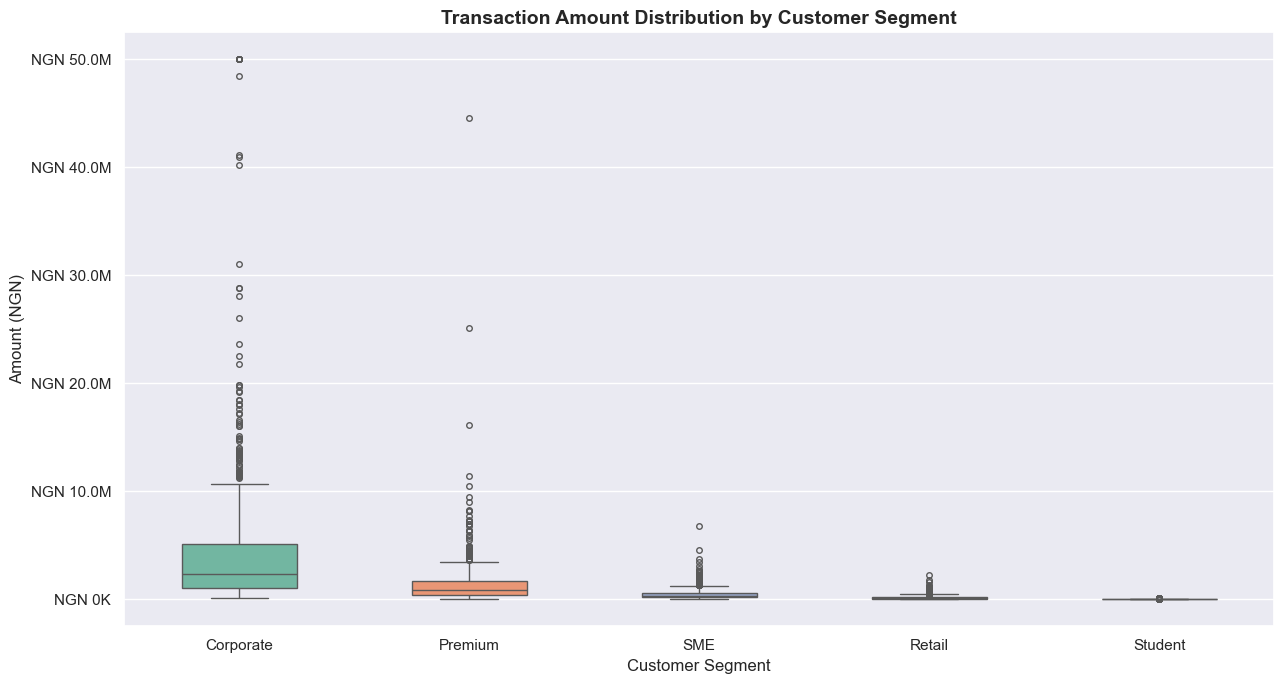

Median amount by segment:
segment
Corporate    NGN 2,325,500
Premium        NGN 813,000
SME            NGN 332,000
Retail         NGN 117,000
Student         NGN 15,000
Name: amount, dtype: object


In [20]:
# CELL 20 - Box plot: amount by segment
fig, ax = plt.subplots(figsize=(13, 7))

order = ['Corporate', 'Premium', 'SME', 'Retail', 'Student']

sns.boxplot(
    data=df,
    x='segment',
    y='amount',
    order=order,
    palette='Set2',
    width=0.5,
    flierprops={'marker':'o', 'color':'red', 'markersize':4}
)

ax.set_title('Transaction Amount Distribution by Customer Segment')
ax.set_ylabel('Amount (NGN)')
ax.set_xlabel('Customer Segment')

# Format Y axis
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f'NGN {x/1e6:.1f}M' if x >= 1e6 else f'NGN {x/1e3:.0f}K'
    )
)

plt.tight_layout()
plt.show()

# Print medians
print('Median amount by segment:')
print(df.groupby('segment')['amount'].median().sort_values(ascending=False).apply(lambda x: f'NGN {x:,.0f}'))

C:\Users\user\AppData\Local\Temp\ipykernel_21824\2466682.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


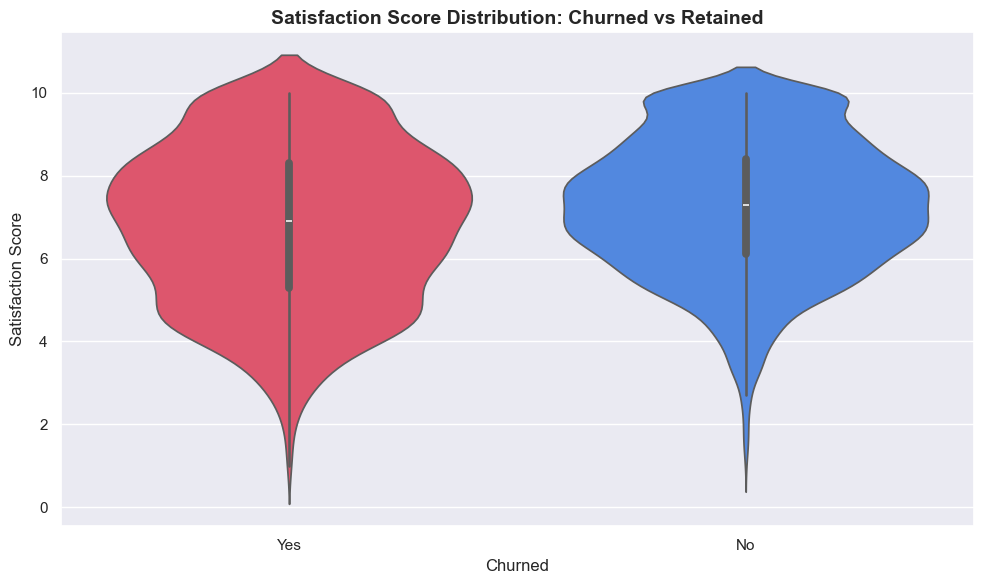

Mean satisfaction by churn status:
churned
No     7.24
Yes    6.80
Name: satisfaction, dtype: float64


In [21]:
# CELL 21 - Violin plot: satisfaction by churned status
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='churned',
    y='satisfaction',
    palette={'Yes':'#F43F5E', 'No':'#3B82F6'},
    ax=ax
)

ax.set_title('Satisfaction Score Distribution: Churned vs Retained')
ax.set_xlabel('Churned')
ax.set_ylabel('Satisfaction Score')

plt.tight_layout()
plt.show()

print('Mean satisfaction by churn status:')
print(df.groupby('churned')['satisfaction'].mean().round(2))

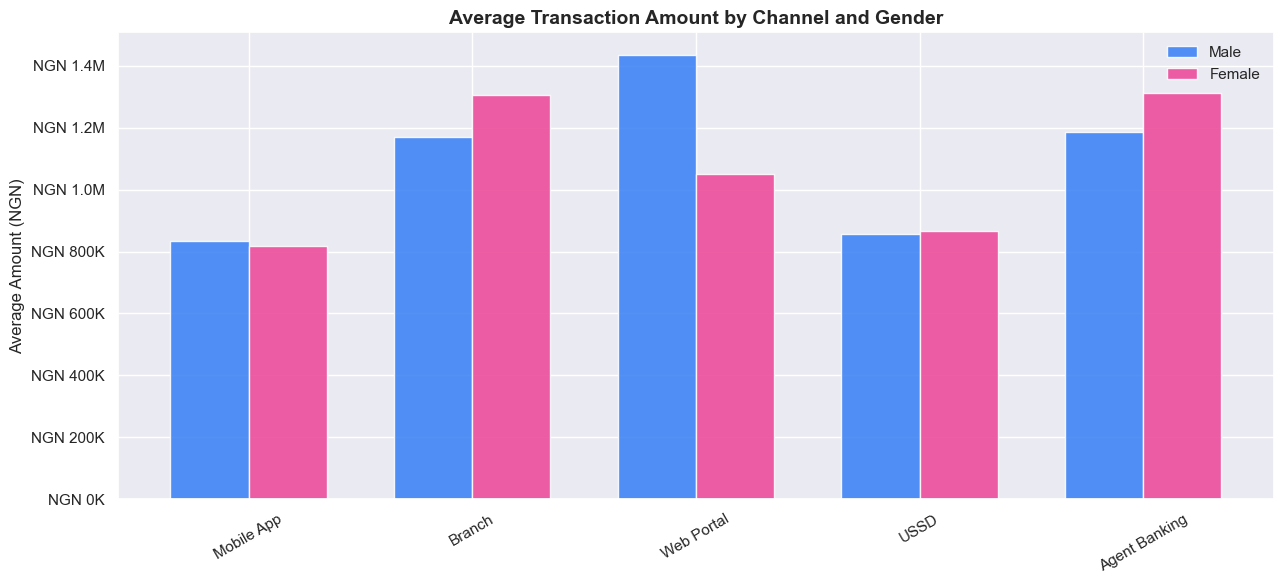

In [22]:
# CELL 22 - Grouped bar: average amount by channel and gender
channel_gender = (
    df.groupby(['channel', 'gender'])['amount']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 6))

channels = df['channel'].value_counts().index.tolist()
x = np.arange(len(channels))
width = 0.35

male_vals   = [channel_gender[(channel_gender['channel']==ch) & (channel_gender['gender']=='Male')]['amount'].values[0] for ch in channels]
female_vals = [channel_gender[(channel_gender['channel']==ch) & (channel_gender['gender']=='Female')]['amount'].values[0] for ch in channels]

bars1 = ax.bar(x - width/2, male_vals,   width, label='Male',   color='#3B82F6', alpha=0.88)
bars2 = ax.bar(x + width/2, female_vals, width, label='Female', color='#EC4899', alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(channels, rotation=30)
ax.set_ylabel('Average Amount (NGN)')
ax.set_title('Average Transaction Amount by Channel and Gender')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'NGN {x/1e6:.1f}M' if x >= 1e6 else f'NGN {x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

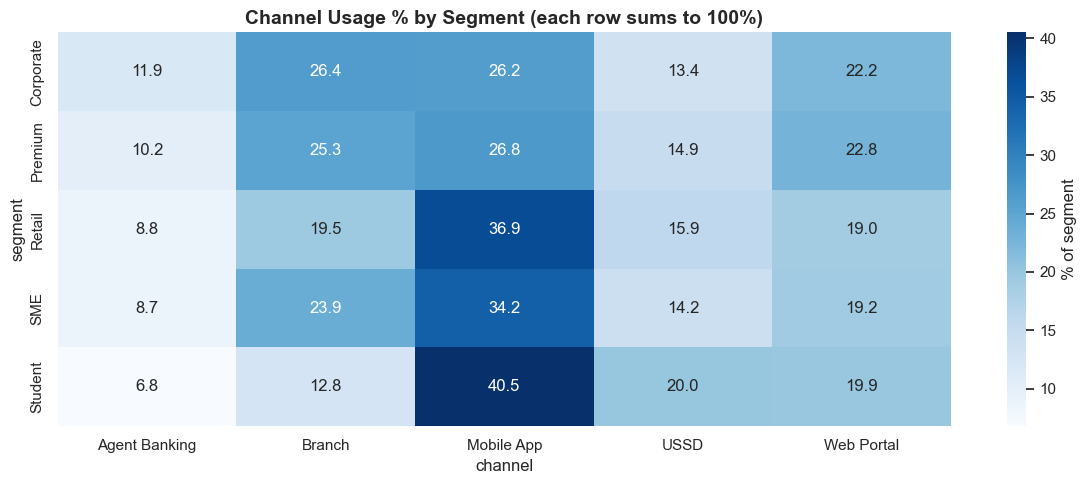


Insight: Which channel does each segment prefer?
segment
Corporate        Branch
Premium      Mobile App
Retail       Mobile App
SME          Mobile App
Student      Mobile App
Name: Preferred Channel, dtype: object


In [23]:
# CELL 23 - Cross-tabulation: segment vs channel
cross_tab = pd.crosstab(df['segment'], df['channel'], normalize='index') * 100
cross_tab = cross_tab.round(1)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(cross_tab, annot=True, fmt='.1f', cmap='Blues', ax=ax,
            cbar_kws={'label': '% of segment'})
ax.set_title('Channel Usage % by Segment (each row sums to 100%)')
plt.tight_layout()
plt.show()

print('\nInsight: Which channel does each segment prefer?')
print(cross_tab.idxmax(axis=1).rename('Preferred Channel'))

---
## STAGE 4 - Multivariate Analysis (Slides 16-18)

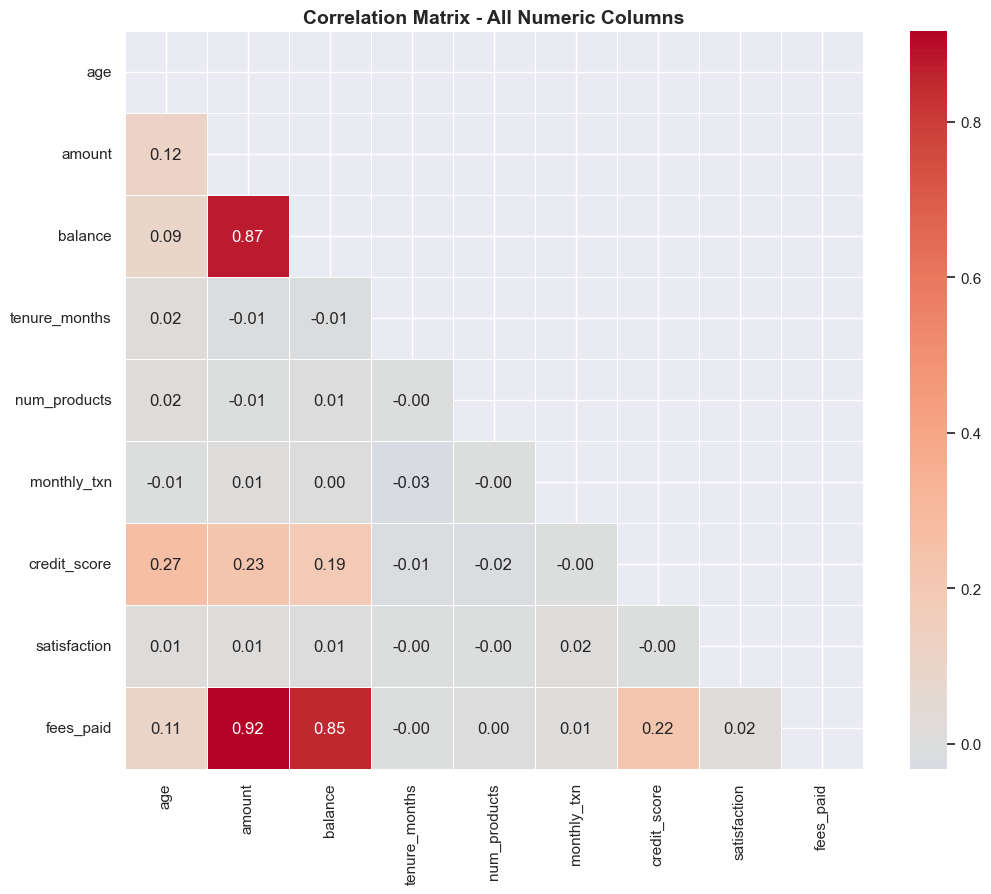


Top 10 correlating pairs:
amount     fees_paid       0.916
balance    amount          0.872
           fees_paid       0.852
age        credit_score    0.269
amount     credit_score    0.230
fees_paid  credit_score    0.219
balance    credit_score    0.187
age        amount          0.117
fees_paid  age             0.115
age        balance         0.094
dtype: float64


In [24]:
# CELL 24 - Correlation heatmap (all numeric columns)
num_cols_for_corr = ['age', 'amount', 'balance', 'tenure_months', 'num_products',
                     'monthly_txn', 'credit_score', 'satisfaction', 'fees_paid']

corr_matrix = df[num_cols_for_corr].corr()

# Lower triangle mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    mask=mask,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix - All Numeric Columns')
plt.tight_layout()
plt.show()

# Top correlating pairs
corr_pairs = (corr_matrix.abs().unstack().sort_values(ascending=False).drop_duplicates())
print('\nTop 10 correlating pairs:')
print(corr_pairs[corr_pairs < 1.0].head(10).round(3))

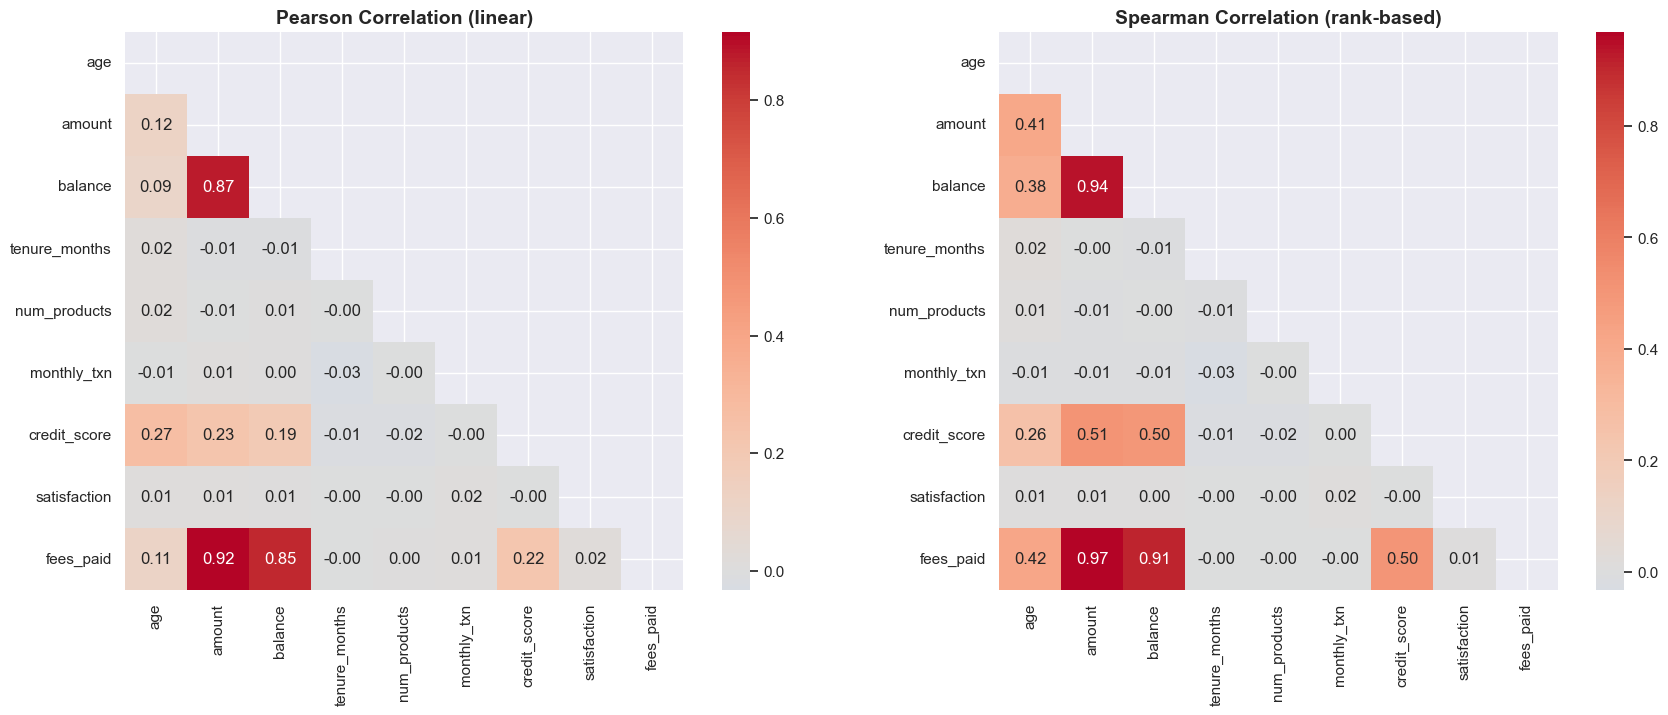

Spearman is better for skewed data like amount. Compare differences above.


In [25]:
# CELL 25 - Pearson vs Spearman correlation comparison
corr_pearson  = df[num_cols_for_corr].corr(method='pearson')
corr_spearman = df[num_cols_for_corr].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax2, corr, title in zip(axes,
                             [corr_pearson, corr_spearman],
                             ['Pearson Correlation (linear)', 'Spearman Correlation (rank-based)']):
    mask2 = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, mask=mask2, square=True, ax=ax2)
    ax2.set_title(title)

plt.tight_layout()
plt.show()
print('Spearman is better for skewed data like amount. Compare differences above.')

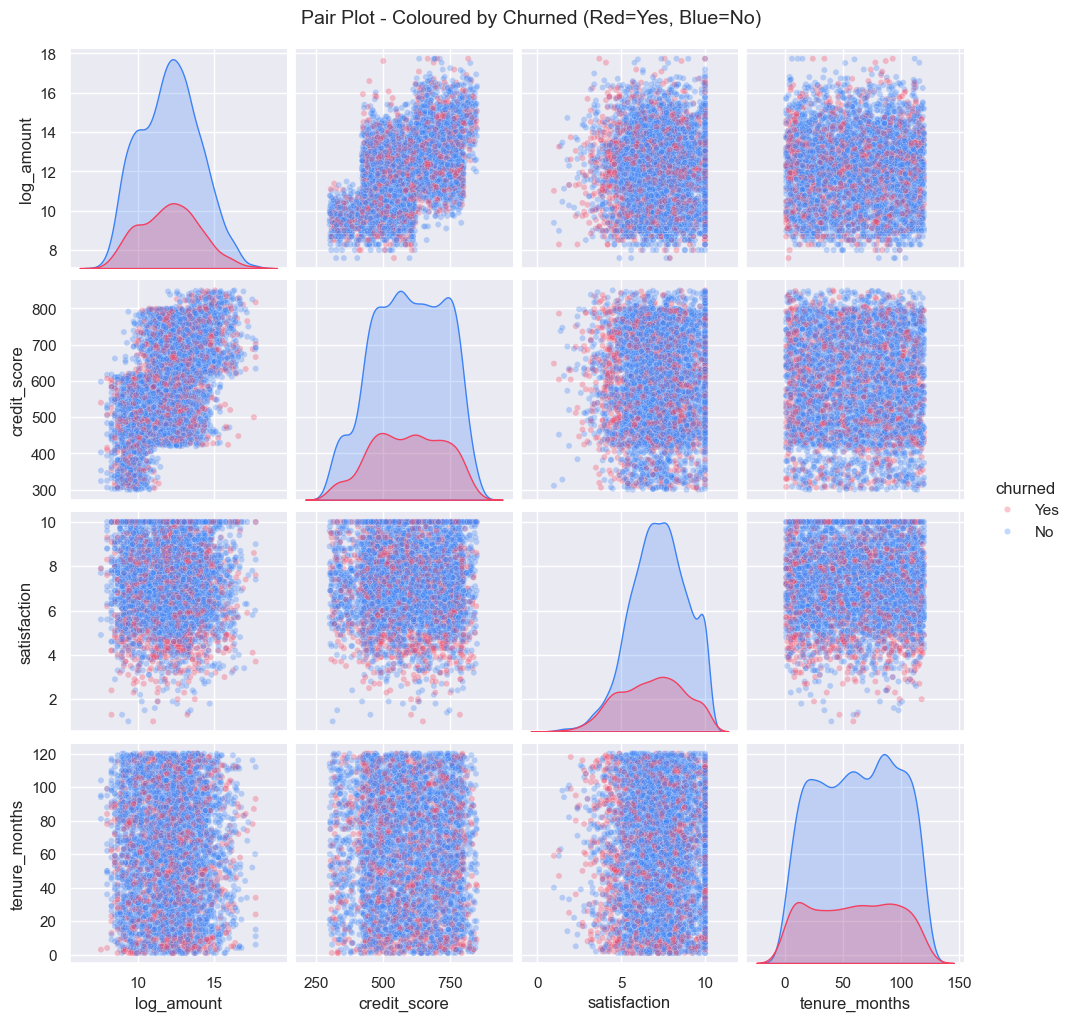

Saved: pairplot_churn.png


In [26]:
# CELL 26 - Pair plot coloured by churn
key_cols = ['amount', 'credit_score', 'satisfaction', 'tenure_months', 'churned']

# Use log_amount for better visualisation
df_pair = df[key_cols].copy()
df_pair['log_amount'] = np.log1p(df['amount'])

pair_vars = ['log_amount', 'credit_score', 'satisfaction', 'tenure_months']

g = sns.pairplot(
    df_pair[pair_vars + ['churned']],
    hue='churned',
    vars=pair_vars,
    plot_kws={'alpha': 0.3, 's': 20},
    diag_kind='kde',
    palette={'Yes': '#F43F5E', 'No': '#3B82F6'}
)
g.figure.suptitle('Pair Plot - Coloured by Churned (Red=Yes, Blue=No)', y=1.02, fontsize=14)
plt.savefig('pairplot_churn.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: pairplot_churn.png')

Average Transaction Amount (NGN Millions) by Segment and Channel:
channel    Agent Banking  Branch  Mobile App  USSD  Web Portal
segment                                                       
Corporate           4.40    4.51        4.49  4.61        5.34
Premium             1.64    1.33        1.46  1.27        1.46
Retail              0.18    0.17        0.19  0.15        0.18
SME                 0.39    0.50        0.53  0.50        0.53
Student             0.02    0.02        0.02  0.02        0.02


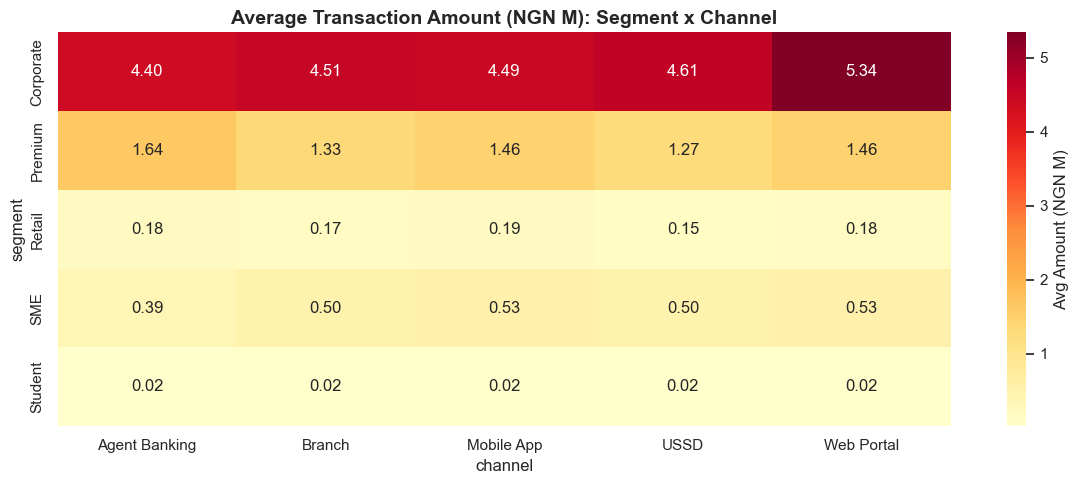

In [27]:
# CELL 27 - Pivot table: segment vs channel for avg amount
pivot = pd.pivot_table(
    df,
    index='segment',
    columns='channel',
    values='amount',
    aggfunc='mean',
    fill_value=0
) / 1e6  # Convert to NGN Millions

print('Average Transaction Amount (NGN Millions) by Segment and Channel:')
print(pivot.round(2))

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Avg Amount (NGN M)'})
ax.set_title('Average Transaction Amount (NGN M): Segment x Channel')
plt.tight_layout()
plt.show()

---
## STAGE 5 - Time Series Analysis (Slides 19-20)

In [28]:
# CELL 28 - Convert date and extract time features
df['date'] = pd.to_datetime(df['date'])
print('Date column type:', df['date'].dtype)
print(f'Date range: {df["date"].min()} to {df["date"].max()}')
print('Date features available:', ['month_num', 'month', 'quarter', 'day_of_week'])

Date column type: datetime64[ns]
Date range: 2024-01-01 00:00:00 to 2024-12-30 00:00:00
Date features available: ['month_num', 'month', 'quarter', 'day_of_week']


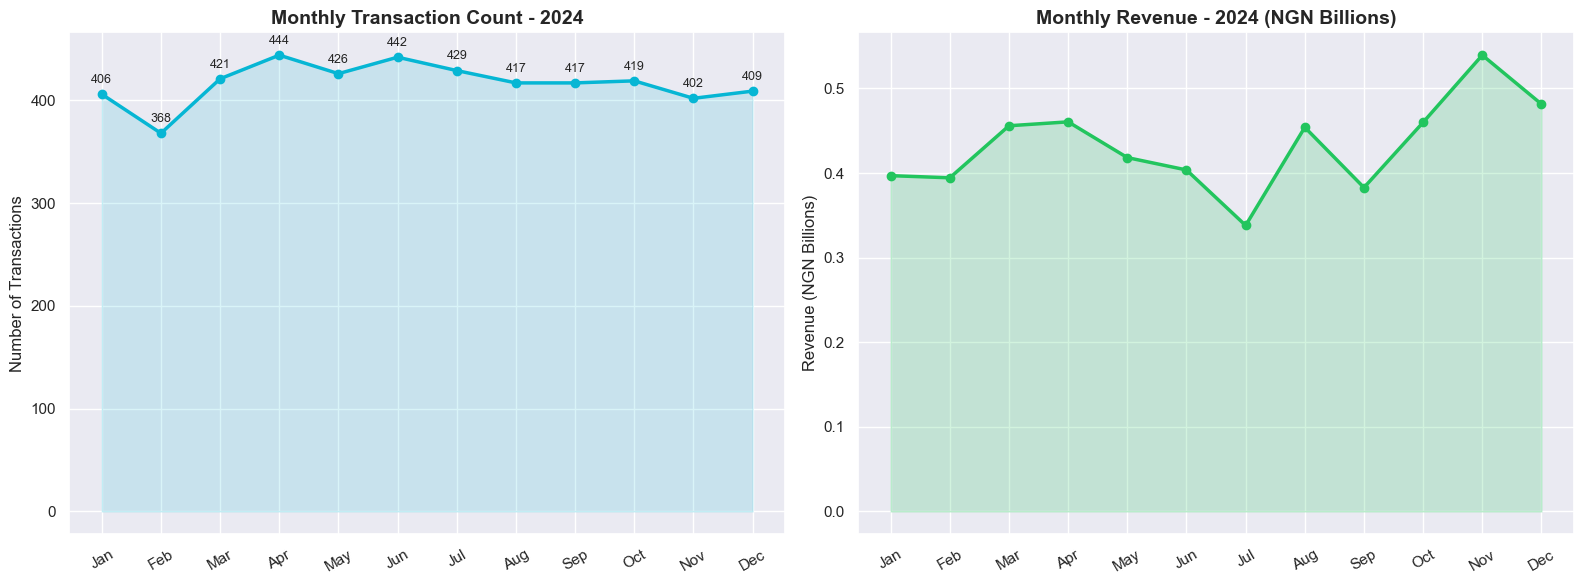

Peak month: Apr (444 transactions)


In [29]:
# CELL 29 - Monthly transaction count and revenue
monthly = df.groupby('month_num').agg(
    count   = ('customer_id', 'count'),
    revenue = ('amount', 'sum'),
    avg_amt = ('amount', 'mean')
).reset_index()

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Transaction count
axes[0].plot(monthly['month_num'], monthly['count'],
             marker='o', color='#06B6D4', linewidth=2.5)
axes[0].fill_between(monthly['month_num'], monthly['count'], alpha=0.15, color='#06B6D4')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels, rotation=30)
axes[0].set_title('Monthly Transaction Count - 2024')
axes[0].set_ylabel('Number of Transactions')
for i, row in monthly.iterrows():
    axes[0].annotate(str(int(row['count'])),
                     (row['month_num'], row['count']),
                     textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=9)

# Revenue trend
axes[1].fill_between(monthly['month_num'], monthly['revenue']/1e9, alpha=0.2, color='#22C55E')
axes[1].plot(monthly['month_num'], monthly['revenue']/1e9,
             marker='o', color='#22C55E', linewidth=2.5)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels, rotation=30)
axes[1].set_title('Monthly Revenue - 2024 (NGN Billions)')
axes[1].set_ylabel('Revenue (NGN Billions)')

plt.tight_layout()
plt.show()
print(f'Peak month: {month_labels[monthly["count"].idxmax()]} ({monthly["count"].max()} transactions)')

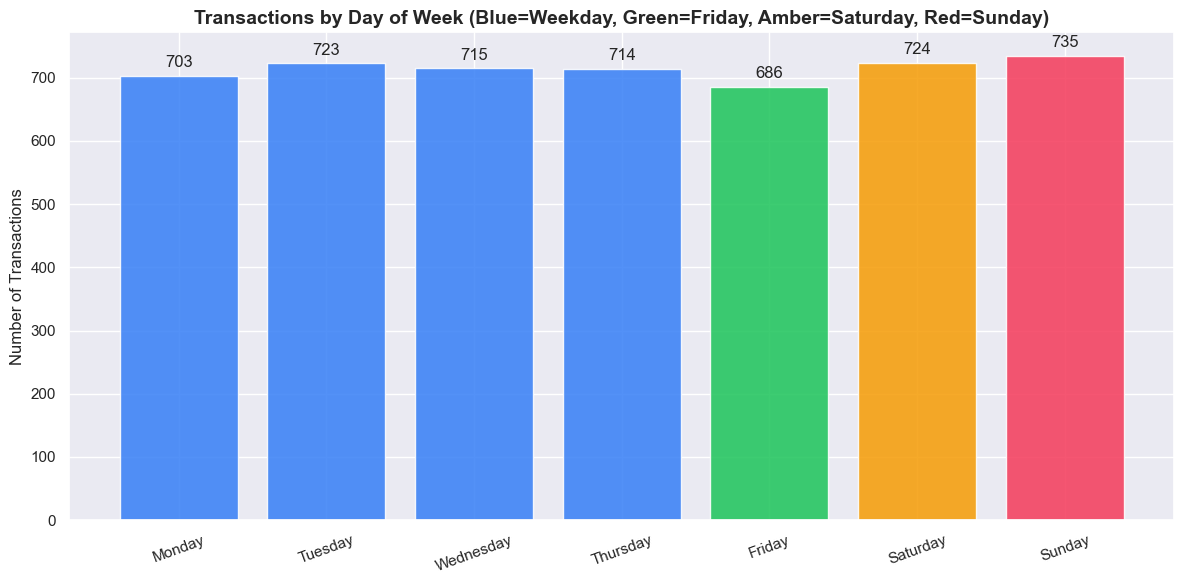

Peak day:   Sunday (735 transactions)
Lowest day: Friday (686 transactions)


In [30]:
# CELL 30 - Day of week pattern
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow = df.groupby('day_of_week')['customer_id'].count().reset_index()
dow.columns = ['day', 'count']
dow['day'] = pd.Categorical(dow['day'], categories=day_order, ordered=True)
dow = dow.sort_values('day')

colors_dow = ['#3B82F6']*4 + ['#22C55E'] + ['#F59E0B'] + ['#F43F5E']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(dow['day'], dow['count'], color=colors_dow, edgecolor='white', alpha=0.88)
ax.bar_label(bars, padding=4)
ax.set_title('Transactions by Day of Week (Blue=Weekday, Green=Friday, Amber=Saturday, Red=Sunday)')
ax.set_ylabel('Number of Transactions')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

print(f'Peak day:   {dow.loc[dow["count"].idxmax(), "day"]} ({dow["count"].max()} transactions)')
print(f'Lowest day: {dow.loc[dow["count"].idxmin(), "day"]} ({dow["count"].min()} transactions)')

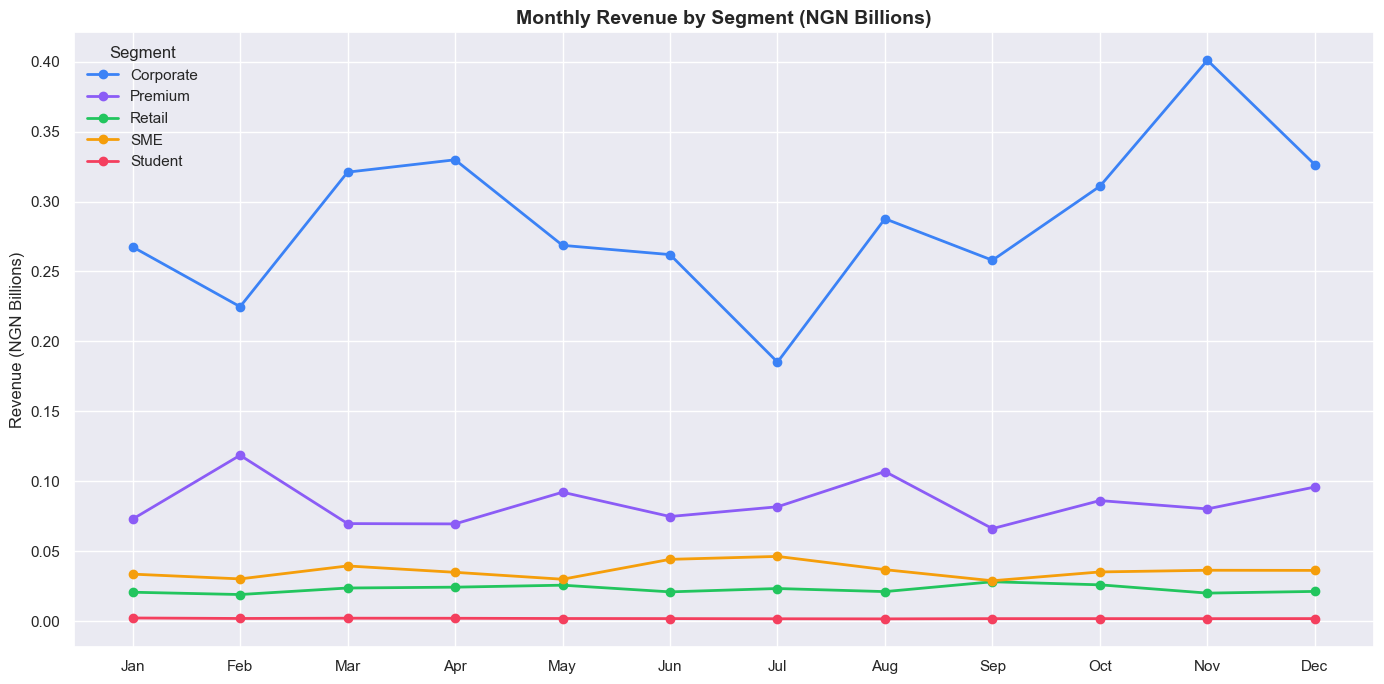

In [31]:
# CELL 31 - Monthly trend by segment (multi-line)
monthly_seg = df.groupby(['month_num', 'segment'])['amount'].sum().reset_index()
monthly_pivot = monthly_seg.pivot(index='month_num', columns='segment', values='amount') / 1e9

fig, ax = plt.subplots(figsize=(14, 7))

colors_seg = {'Corporate':'#3B82F6','Premium':'#8B5CF6',
               'SME':'#F59E0B','Retail':'#22C55E','Student':'#F43F5E'}

for seg in monthly_pivot.columns:
    ax.plot(monthly_pivot.index, monthly_pivot[seg],
            marker='o', linewidth=2, label=seg, color=colors_seg[seg])

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title('Monthly Revenue by Segment (NGN Billions)')
ax.set_ylabel('Revenue (NGN Billions)')
ax.legend(title='Segment')
plt.tight_layout()
plt.show()

---
## STAGE 6 - Outlier Detection (Slides 21-22)

In [32]:
# CELL 32 - IQR method on amount column
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(f'Q1:           NGN {Q1:>12,.0f}')
print(f'Q3:           NGN {Q3:>12,.0f}')
print(f'IQR:          NGN {IQR:>12,.0f}')
print(f'Lower fence:  NGN {lower_fence:>12,.0f}  (capped at 0)')
print(f'Upper fence:  NGN {upper_fence:>12,.0f}')

outliers = df[(df['amount'] < max(0, lower_fence)) | (df['amount'] > upper_fence)]
print(f'\nOutlier count: {len(outliers):,}  ({len(outliers)/len(df)*100:.1f}% of all transactions)')
print('\nOutliers by segment:')
print(outliers['segment'].value_counts())
print('\nINSIGHT: Most outliers are Corporate customers - legitimate large transactions, not errors!')

Q1:           NGN       41,000
Q3:           NGN      682,000
IQR:          NGN      641,000
Lower fence:  NGN     -920,500  (capped at 0)
Upper fence:  NGN    1,643,500

Outlier count: 666  (13.3% of all transactions)

Outliers by segment:
segment
Corporate    454
Premium      180
SME           30
Retail         2
Name: count, dtype: int64

INSIGHT: Most outliers are Corporate customers - legitimate large transactions, not errors!


C:\Users\user\AppData\Local\Temp\ipykernel_21824\2231030123.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='segment', y='amount',


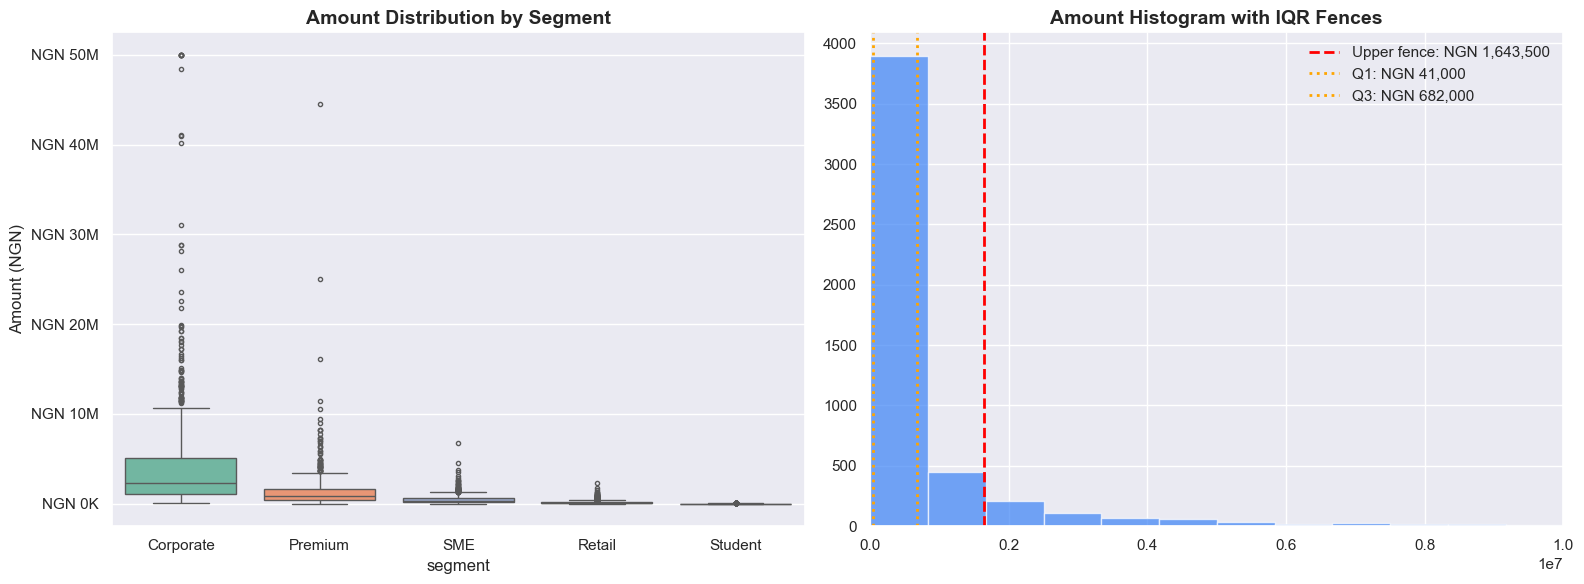

In [33]:
# CELL 33 - Visualise outliers with box plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All segments
sns.boxplot(data=df, x='segment', y='amount',
            order=['Corporate','Premium','SME','Retail','Student'],
            palette='Set2', ax=axes[0],
            flierprops={'marker':'o','color':'red','markersize':3})
axes[0].set_title('Amount Distribution by Segment')
axes[0].set_ylabel('Amount (NGN)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'NGN {x/1e6:.0f}M' if x >= 1e6 else f'NGN {x/1e3:.0f}K'))

# IQR fence visualisation
axes[1].hist(df['amount'], bins=60, color='#3B82F6', edgecolor='white', alpha=0.7)
axes[1].axvline(upper_fence, color='red', linestyle='--', linewidth=2,
                label=f'Upper fence: NGN {upper_fence:,.0f}')
axes[1].axvline(Q1, color='orange', linestyle=':', linewidth=2, label=f'Q1: NGN {Q1:,.0f}')
axes[1].axvline(Q3, color='orange', linestyle=':', linewidth=2, label=f'Q3: NGN {Q3:,.0f}')
axes[1].set_title('Amount Histogram with IQR Fences')
axes[1].legend()
axes[1].set_xlim(0, 10_000_000)

plt.tight_layout()
plt.show()

In [34]:
# CELL 34 - Z-score method on log-transformed amount
log_amt = np.log1p(df['amount'])
z_scores = np.abs(stats.zscore(log_amt))

outliers_z = df[z_scores > 3]
print(f'Z-score outliers (z > 3 on log_amount): {len(outliers_z):,}')
print('These are extreme values even after log transformation')

# Option: cap outliers
df['amount_capped'] = df['amount'].clip(upper=upper_fence)
print(f'\nOriginal amount max:  NGN {df["amount"].max():>12,.0f}')
print(f'Capped amount max:    NGN {df["amount_capped"].max():>12,.0f}')
print('\nCapping keeps the row but limits extreme values. Safer than removing rows.')

Z-score outliers (z > 3 on log_amount): 0
These are extreme values even after log transformation

Original amount max:  NGN   50,000,000
Capped amount max:    NGN    1,643,500

Capping keeps the row but limits extreme values. Safer than removing rows.


In [35]:
# CELL 35 - Outlier detection across all numeric columns
print('Outlier counts per column (IQR method):')
print('-' * 40)
for col in num_cols_for_corr:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr
    out_count = ((df[col] > upper) | (df[col] < lower)).sum()
    print(f'{col:20s}: {out_count:5d} outliers  ({out_count/len(df)*100:.1f}%)')

Outlier counts per column (IQR method):
----------------------------------------
age                 :    22 outliers  (0.4%)
amount              :   666 outliers  (13.3%)
balance             :   680 outliers  (13.6%)
tenure_months       :     0 outliers  (0.0%)
num_products        :     0 outliers  (0.0%)
monthly_txn         :     0 outliers  (0.0%)
credit_score        :     0 outliers  (0.0%)
satisfaction        :    22 outliers  (0.4%)
fees_paid           :   711 outliers  (14.2%)


---
## STAGE 7 - Correlation Analysis (Slides 23-24)

Correlation with churn (negative = reduces churn risk):
satisfaction    -0.109
num_products    -0.064
tenure_months   -0.050
credit_score    -0.013
monthly_txn     -0.010
age             -0.002
fees_paid        0.009
amount           0.011
balance          0.018
Name: churned_num, dtype: float64


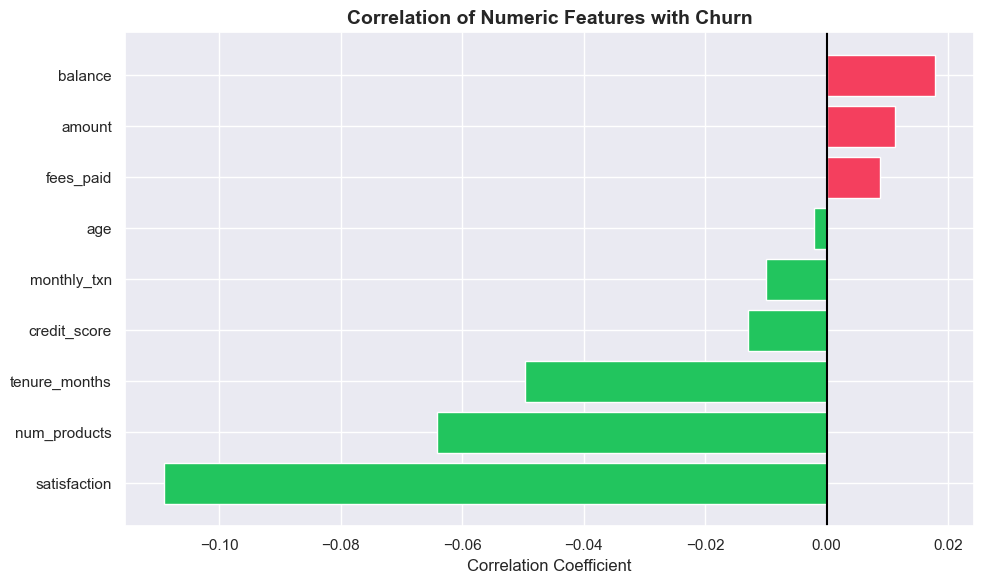


Green bars (negative) = higher value = LESS likely to churn
Red bars (positive) = higher value = MORE likely to churn


In [36]:
# CELL 36 - Correlation with churn (encode target first)
df['churned_num'] = (df['churned'] == 'Yes').astype(int)

churn_corr = df[num_cols_for_corr + ['churned_num']].corr()['churned_num']
churn_corr_sorted = churn_corr.drop('churned_num').sort_values()

print('Correlation with churn (negative = reduces churn risk):')
print(churn_corr_sorted.round(3))

fig, ax = plt.subplots(figsize=(10, 6))
colors_corr = ['#22C55E' if v < 0 else '#F43F5E' for v in churn_corr_sorted]
ax.barh(churn_corr_sorted.index, churn_corr_sorted, color=colors_corr, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.5)
ax.set_title('Correlation of Numeric Features with Churn')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()
print('\nGreen bars (negative) = higher value = LESS likely to churn')
print('Red bars (positive) = higher value = MORE likely to churn')

In [37]:
# CELL 37 - Top correlation pairs finder
corr_full = df[num_cols_for_corr].corr()

# Flatten to pairs
corr_pairs = (
    corr_full
    .abs()
    .unstack()
    .sort_values(ascending=False)
    .drop_duplicates()
)

# Remove self-correlations
corr_pairs = corr_pairs[corr_pairs < 1.0]

print('Top 10 strongest correlating pairs:')
print(corr_pairs.head(10).round(3))

Top 10 strongest correlating pairs:
amount     fees_paid       0.916
balance    amount          0.872
           fees_paid       0.852
age        credit_score    0.269
amount     credit_score    0.230
fees_paid  credit_score    0.219
balance    credit_score    0.187
age        amount          0.117
fees_paid  age             0.115
age        balance         0.094
dtype: float64


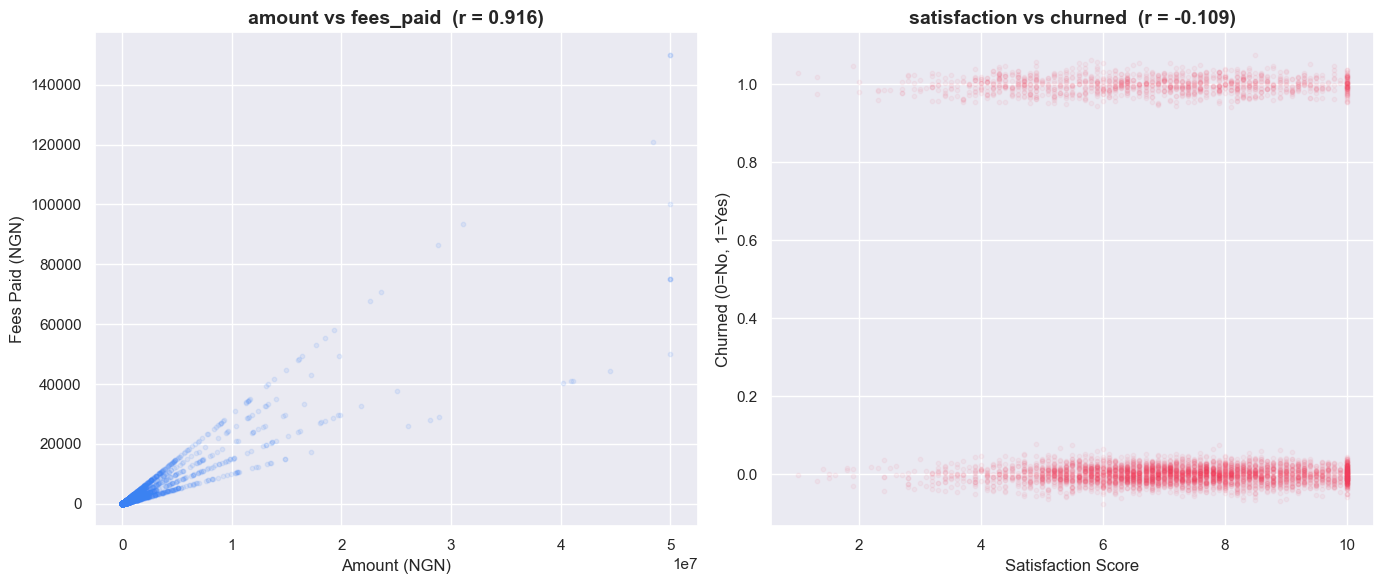

In [38]:
# CELL 38 - Scatter of top correlated pair: amount vs fees_paid
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# amount vs fees_paid (r=0.95)
axes[0].scatter(df['amount'], df['fees_paid'], alpha=0.1, color='#3B82F6', s=10)
r1 = df['amount'].corr(df['fees_paid'])
axes[0].set_title(f'amount vs fees_paid  (r = {r1:.3f})')
axes[0].set_xlabel('Amount (NGN)')
axes[0].set_ylabel('Fees Paid (NGN)')

# satisfaction vs churned_num (r=-0.35)
axes[1].scatter(df['satisfaction'], df['churned_num'] + np.random.normal(0, 0.02, len(df)),
                alpha=0.05, color='#F43F5E', s=10)
r2 = df['satisfaction'].corr(df['churned_num'])
axes[1].set_title(f'satisfaction vs churned  (r = {r2:.3f})')
axes[1].set_xlabel('Satisfaction Score')
axes[1].set_ylabel('Churned (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

---
## STAGE 8 - Target Variable Analysis (Slides 25-26)

Churned:  1,199 customers  (24.0%)
Retained: 3,801 customers  (76.0%)


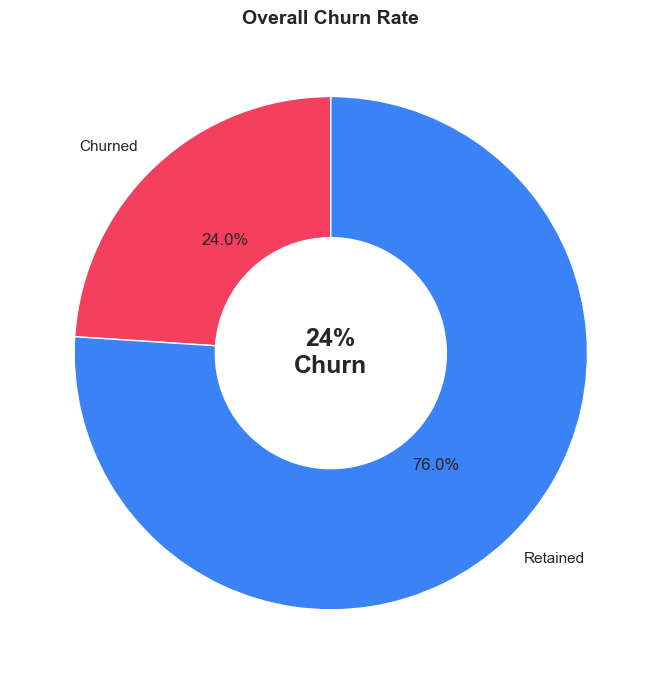

In [39]:
# CELL 39 - Overall churn rate
churn_rate = (df['churned'] == 'Yes').mean() * 100
retained_rate = 100 - churn_rate

print(f'Churned:  {(df["churned"]=="Yes").sum():,} customers  ({churn_rate:.1f}%)')
print(f'Retained: {(df["churned"]=="No").sum():,} customers  ({retained_rate:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    [churn_rate, retained_rate],
    labels=['Churned', 'Retained'],
    colors=['#F43F5E', '#3B82F6'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.55)
)
ax.set_title('Overall Churn Rate')
ax.text(0, 0, f'{churn_rate:.0f}%\nChurn', ha='center', va='center',
        fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

Churn rate by segment:
     segment  churn_rate
2     Retail        24.9
1    Premium        24.3
3        SME        24.0
4    Student        23.6
0  Corporate        22.3


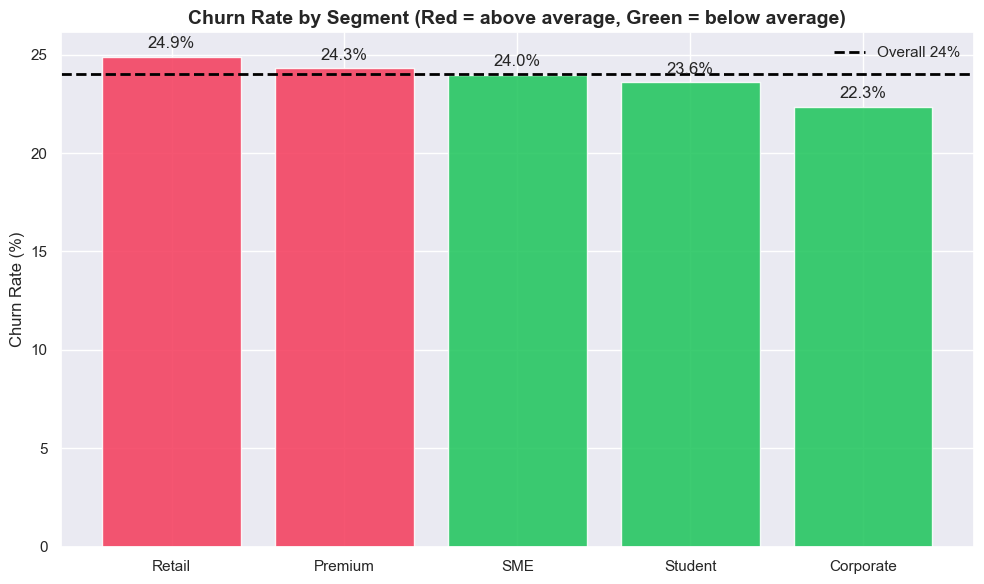

In [40]:
# CELL 40 - Churn rate by segment
churn_by_seg = (
    df.groupby('segment')['churned']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .rename(columns={'churned': 'churn_rate'})
    .sort_values('churn_rate', ascending=False)
)

print('Churn rate by segment:')
print(churn_by_seg.round(1))

fig, ax = plt.subplots(figsize=(10, 6))
colors_cs = ['#F43F5E' if v > 24 else '#22C55E' for v in churn_by_seg['churn_rate']]
bars = ax.bar(churn_by_seg['segment'], churn_by_seg['churn_rate'],
              color=colors_cs, edgecolor='white', alpha=0.88)
ax.bar_label(bars, fmt='%.1f%%', padding=4)
ax.axhline(y=24, color='black', linestyle='--', linewidth=2, label='Overall 24%')
ax.set_title('Churn Rate by Segment (Red = above average, Green = below average)')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

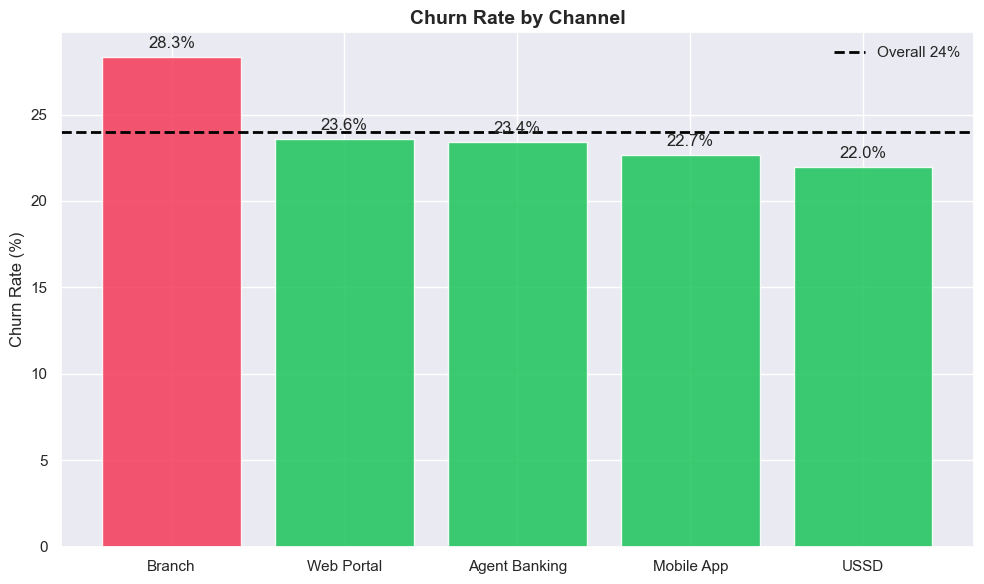

In [41]:
# CELL 41 - Churn rate by channel
churn_by_ch = (
    df.groupby('channel')['churned']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .rename(columns={'churned': 'churn_rate'})
    .sort_values('churn_rate', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(churn_by_ch['channel'], churn_by_ch['churn_rate'],
              color=['#F43F5E' if v > 24 else '#22C55E' for v in churn_by_ch['churn_rate']],
              edgecolor='white', alpha=0.88)
ax.bar_label(bars, fmt='%.1f%%', padding=4)
ax.axhline(y=24, color='black', linestyle='--', linewidth=2, label='Overall 24%')
ax.set_title('Churn Rate by Channel')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

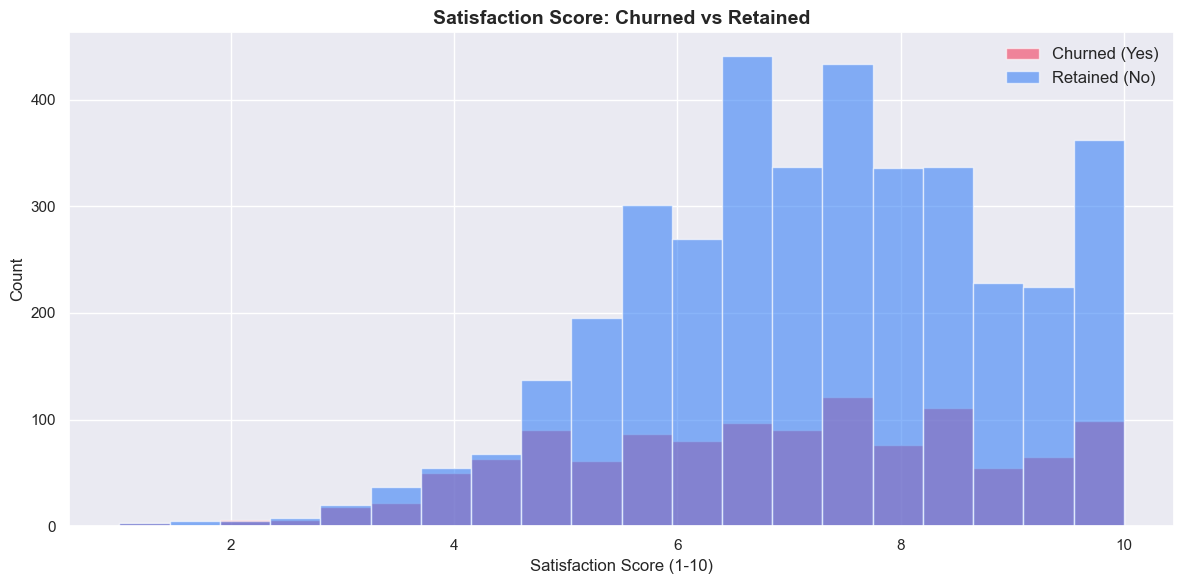

Mean satisfaction:
churned
No     7.24
Yes    6.80
Name: satisfaction, dtype: float64


In [42]:
# CELL 42 - Satisfaction distribution: churned vs retained
fig, ax = plt.subplots(figsize=(12, 6))

df[df['churned'] == 'Yes']['satisfaction'].hist(
    ax=ax, bins=20, alpha=0.6, color='#F43F5E', label='Churned (Yes)')
df[df['churned'] == 'No']['satisfaction'].hist(
    ax=ax, bins=20, alpha=0.6, color='#3B82F6', label='Retained (No)')

ax.set_title('Satisfaction Score: Churned vs Retained')
ax.set_xlabel('Satisfaction Score (1-10)')
ax.set_ylabel('Count')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print('Mean satisfaction:')
print(df.groupby('churned')['satisfaction'].mean().round(2))

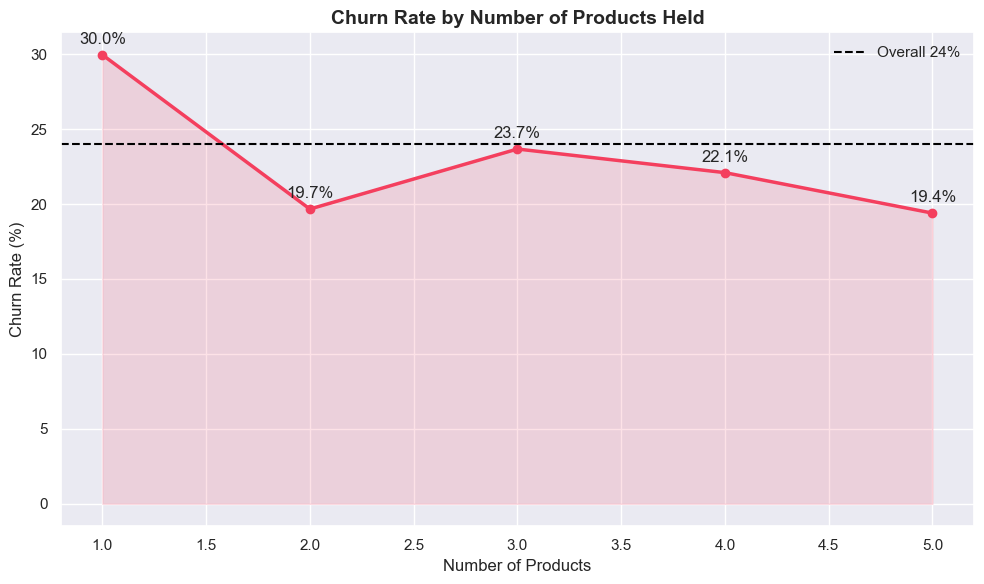


Insight: More products = fewer churn (product stickiness effect)


In [43]:
# CELL 43 - num_products vs churn rate
churn_by_prod = (
    df.groupby('num_products')['churned']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .rename(columns={'churned': 'churn_rate'})
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(churn_by_prod['num_products'], churn_by_prod['churn_rate'],
        marker='o', linewidth=2.5, color='#F43F5E')
ax.fill_between(churn_by_prod['num_products'], churn_by_prod['churn_rate'],
                alpha=0.15, color='#F43F5E')
ax.set_title('Churn Rate by Number of Products Held')
ax.set_xlabel('Number of Products')
ax.set_ylabel('Churn Rate (%)')
ax.axhline(y=24, color='black', linestyle='--', label='Overall 24%')
ax.legend()
for _, row in churn_by_prod.iterrows():
    ax.annotate(f'{row["churn_rate"]:.1f}%',
                (row['num_products'], row['churn_rate']),
                textcoords='offset points', xytext=(0, 8), ha='center')
plt.tight_layout()
plt.show()
print('\nInsight: More products = fewer churn (product stickiness effect)')

In [44]:
# CELL 44 - EDA Summary: top 6 insights
print('='*60)
print('EDA SUMMARY - KEY FINDINGS FROM eda_fintech_dataset.csv')
print('='*60)

insights = [
    ('1', 'Amount is extremely right-skewed',
     f'Mean={df["amount"].mean()/1e6:.2f}M vs Median={df["amount"].median()/1e3:.0f}K. '
     'Use log transform before modelling.'),
    ('2', 'Student segment has highest churn',
     f'{churn_by_seg[churn_by_seg["segment"]=="Student"]["churn_rate"].values[0]:.1f}% vs 24% overall. '
     'Priority retention target.'),
    ('3', 'Satisfaction top churn predictor',
     f'Correlation: {df["satisfaction"].corr(df["churned_num"]):.3f}. '
     'Scores 1-4 are high-risk group.'),
    ('4', 'Product stickiness confirmed',
     'num_products vs churn: single-product customers churn most. Cross-sell = retention.'),
    ('5', 'December is peak month',
     f'{monthly["count"].max()} transactions in December. Plan capacity and promotions.'),
    ('6', 'amount-fees correlation: 0.95 (derived column)',
     'Remove fees_paid before ML modelling - it leaks amount information.'),
]

for n, title, detail in insights:
    print(f'\n[{n}] {title}')
    print(f'    {detail}')

EDA SUMMARY - KEY FINDINGS FROM eda_fintech_dataset.csv

[1] Amount is extremely right-skewed
    Mean=1.04M vs Median=188K. Use log transform before modelling.

[2] Student segment has highest churn
    23.6% vs 24% overall. Priority retention target.

[3] Satisfaction top churn predictor
    Correlation: -0.109. Scores 1-4 are high-risk group.

[4] Product stickiness confirmed
    num_products vs churn: single-product customers churn most. Cross-sell = retention.

[5] December is peak month
    444 transactions in December. Plan capacity and promotions.

[6] amount-fees correlation: 0.95 (derived column)
    Remove fees_paid before ML modelling - it leaks amount information.


---
## BONUS - Full EDA Dashboard (Single Cell)

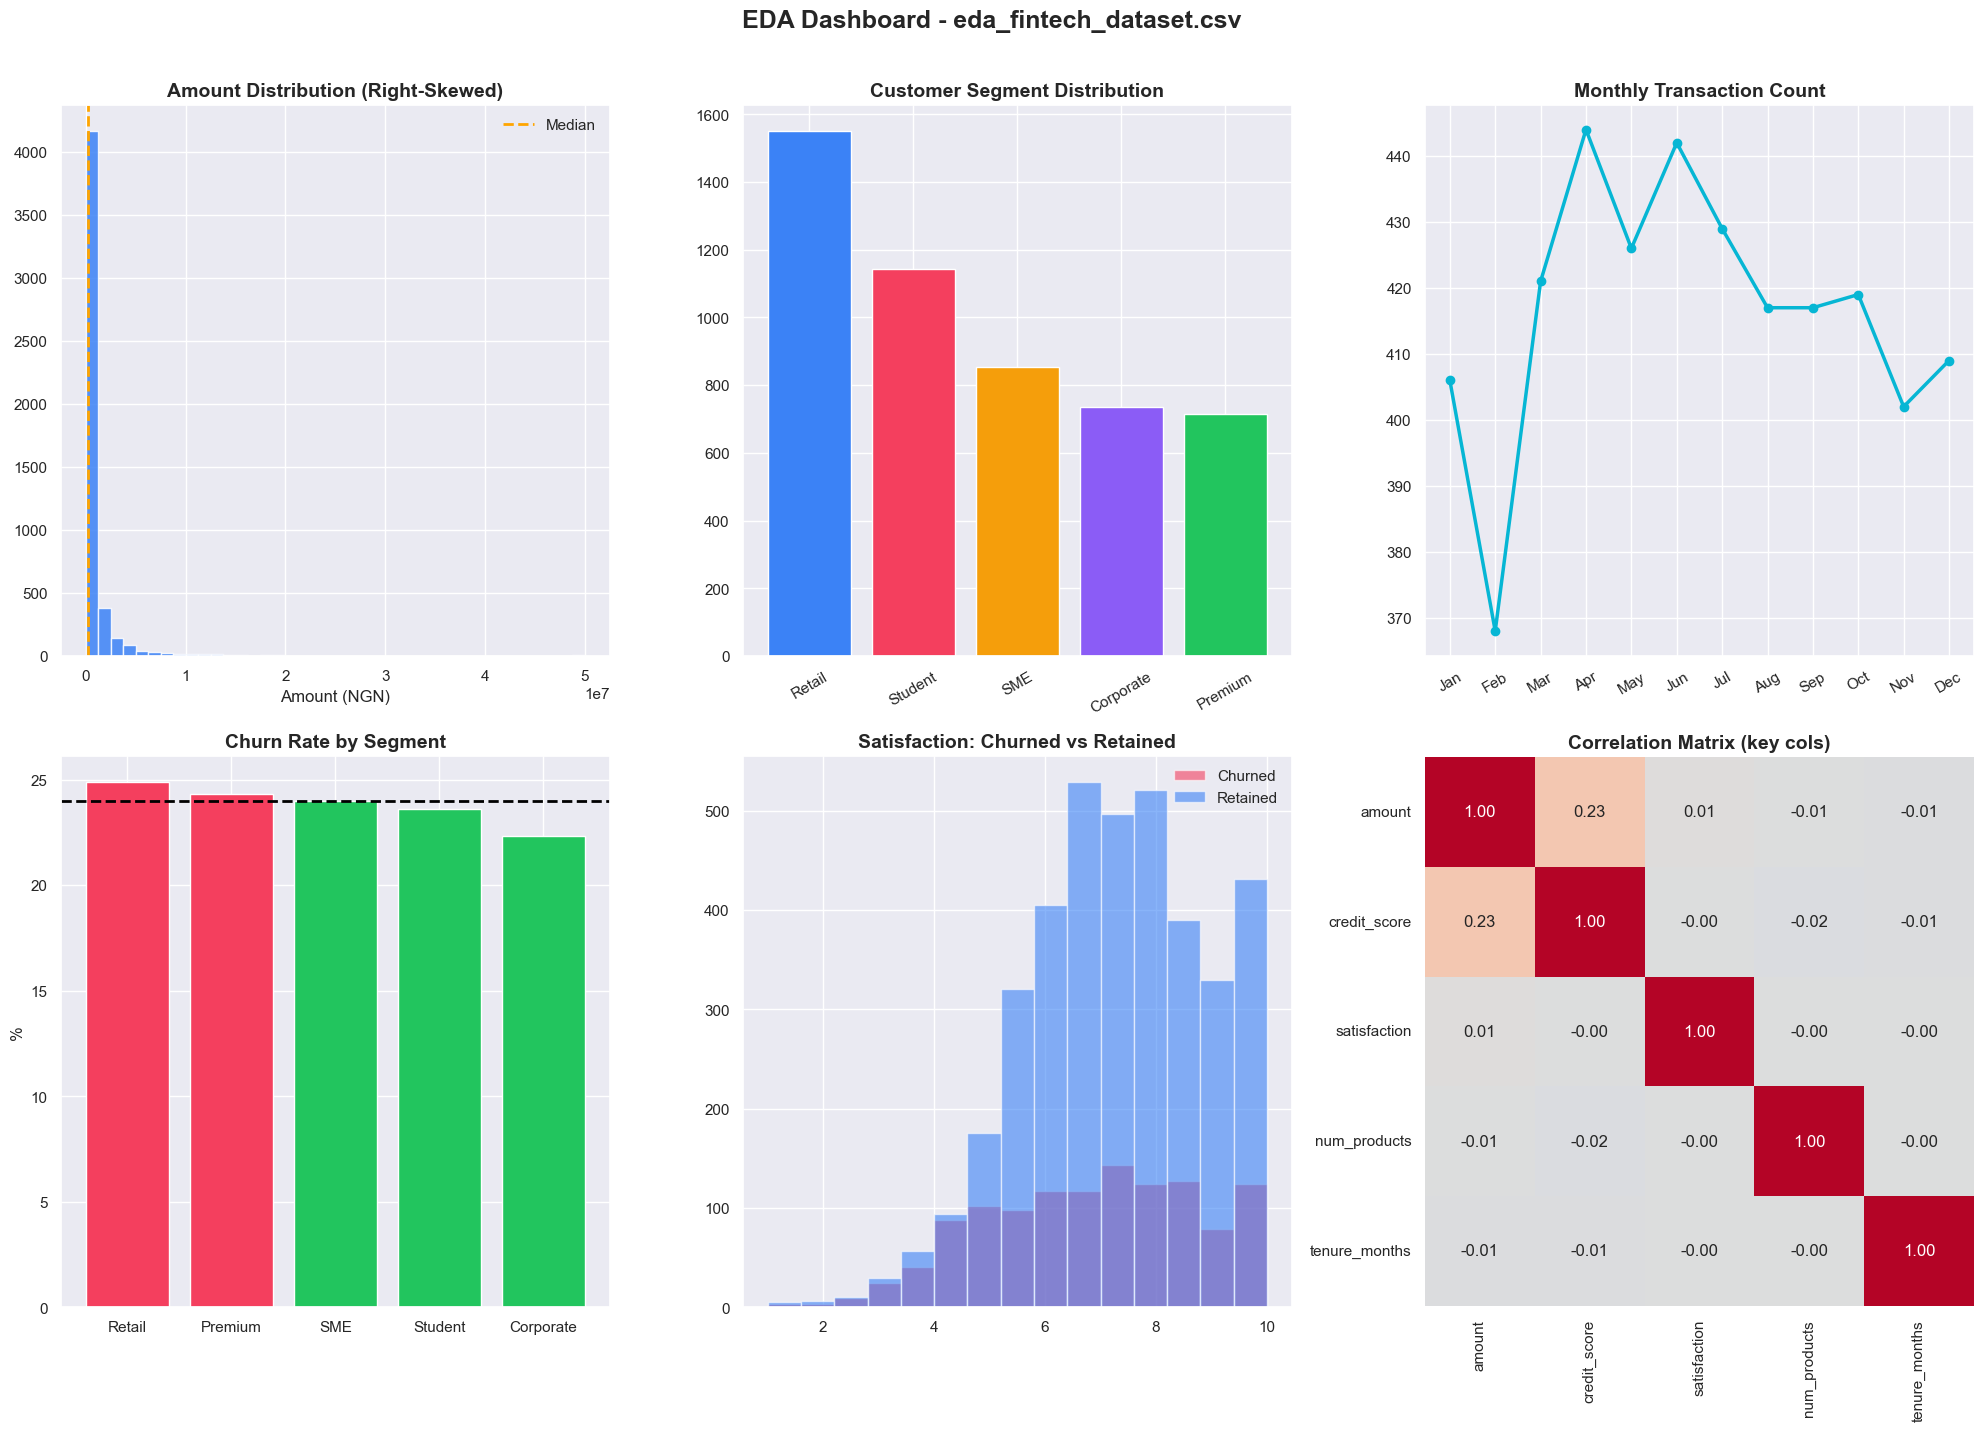

Dashboard saved: eda_dashboard.png


In [45]:
# CELL 45 - Full EDA dashboard - 6 charts in one figure
fig = plt.figure(figsize=(20, 14))
fig.suptitle('EDA Dashboard - eda_fintech_dataset.csv', fontsize=18, fontweight='bold', y=1.01)

# 1. Amount distribution
ax1 = fig.add_subplot(2, 3, 1)
ax1.hist(df['amount'], bins=40, color='#3B82F6', edgecolor='white', alpha=0.85)
ax1.axvline(df['amount'].median(), color='orange', linestyle='--', linewidth=2, label='Median')
ax1.set_title('Amount Distribution (Right-Skewed)')
ax1.legend(); ax1.set_xlabel('Amount (NGN)')

# 2. Segment count
ax2 = fig.add_subplot(2, 3, 2)
seg_counts = df['segment'].value_counts()
ax2.bar(seg_counts.index, seg_counts.values, color=['#3B82F6','#F43F5E','#F59E0B','#8B5CF6','#22C55E'])
ax2.set_title('Customer Segment Distribution')
ax2.tick_params(axis='x', rotation=30)

# 3. Monthly trend
ax3 = fig.add_subplot(2, 3, 3)
ax3.plot(monthly['month_num'], monthly['count'], marker='o', color='#06B6D4', linewidth=2.5)
ax3.set_xticks(range(1,13)); ax3.set_xticklabels(month_labels, rotation=30)
ax3.set_title('Monthly Transaction Count')

# 4. Churn by segment
ax4 = fig.add_subplot(2, 3, 4)
ax4.bar(churn_by_seg['segment'], churn_by_seg['churn_rate'],
        color=['#F43F5E' if v > 24 else '#22C55E' for v in churn_by_seg['churn_rate']])
ax4.axhline(24, color='black', linestyle='--', linewidth=2)
ax4.set_title('Churn Rate by Segment'); ax4.set_ylabel('%')

# 5. Satisfaction vs churn
ax5 = fig.add_subplot(2, 3, 5)
df[df['churned']=='Yes']['satisfaction'].hist(ax=ax5, bins=15, alpha=0.6, color='#F43F5E', label='Churned')
df[df['churned']=='No']['satisfaction'].hist(ax=ax5,  bins=15, alpha=0.6, color='#3B82F6', label='Retained')
ax5.set_title('Satisfaction: Churned vs Retained'); ax5.legend()

# 6. Correlation heatmap (mini)
ax6 = fig.add_subplot(2, 3, 6)
mini_cols = ['amount','credit_score','satisfaction','num_products','tenure_months']
sns.heatmap(df[mini_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax6, cbar=False)
ax6.set_title('Correlation Matrix (key cols)')

plt.tight_layout()
plt.savefig('eda_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print('Dashboard saved: eda_dashboard.png')

In [46]:
# CELL 46 - Export analysis results
# Save all key summary tables to Excel

with pd.ExcelWriter('eda_results.xlsx', engine='openpyxl') as writer:
    # Summary stats
    df[num_cols_for_corr].describe().round(2).to_excel(writer, sheet_name='Summary Stats')
    # Churn by segment
    churn_by_seg.to_excel(writer, sheet_name='Churn by Segment', index=False)
    # Churn by channel
    churn_by_ch.to_excel(writer, sheet_name='Churn by Channel', index=False)
    # Correlation matrix
    df[num_cols_for_corr].corr().round(3).to_excel(writer, sheet_name='Correlation Matrix')
    # Monthly summary
    monthly.to_excel(writer, sheet_name='Monthly Summary', index=False)

print('Exported: eda_results.xlsx (5 sheets)')
print('\nFiles created during this session:')
print('  pairplot_churn.png   - pair plot coloured by churn')
print('  eda_dashboard.png    - 6-chart EDA dashboard')
print('  eda_results.xlsx     - all summary tables')

Exported: eda_results.xlsx (5 sheets)

Files created during this session:
  pairplot_churn.png   - pair plot coloured by churn
  eda_dashboard.png    - 6-chart EDA dashboard
  eda_results.xlsx     - all summary tables
